# Live2026 forecast — cached downloads and fresh inference

**Run All checks source freshness every time.** Public sources are downloaded when the successful-check cache is older than six hours; FORCE=True bypasses that cache. Changed sources trigger cleanup/alignment and new predictions. All outputs are timestamped.

Failed providers use verified cached data with explicit stale status. STRICT=True fails instead. OFFLINE=True deliberately disables downloads. The table below distinguishes checks from the dates of actual observations. Do not describe a cached feature as newly observed.

The2026 model checkpoint, historical fits and normalizers stay fixed. New polls and feature values update its inference. Political control after its September17 review is explicitly carried forward as a scenario assumption. Candidate changes remain subject to the reviewed screening policy.

In [2]:
from pathlib import Path
import sys, json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
ROOT = next(p for p in [Path.cwd(), Path.cwd().parent] if (p/'election_lab.py').exists())
sys.path.insert(0, str(ROOT))
import election_lab as lab
from model_labels import display, model_label
pd.set_option('display.max_rows', 40)

FORCE = False
OFFLINE = False
STRICT = False
INCLUDE_STUDENT = True
TTL_HOURS = 6
TIMEOUT_SECONDS = 15
from live_share_images import (chamber_images, state_images, uncertainty_images, watch_images, published_images, display_images)


## 1. Download/check, prepare and predict

This is the entire supported data-to-model handoff. Verbose download/preparation output is saved to the run log. A failed preparation preserves the last successful forecast.

In [3]:
RUN=lab.run_logged(lab.refresh,force=FORCE,offline=OFFLINE,strict=STRICT,ttl_hours=TTL_HOURS,timeout=TIMEOUT_SECONDS,include_student=INCLUDE_STUDENT)
meta=json.loads((RUN/'run.json').read_text())
print('Forecast:',RUN.relative_to(ROOT),'| Cutoff:',meta['as_of'])
print('Training through:',meta['trained_through'],'| Political review:',meta['political_reference_reviewed_through'],'| Carried forward:',meta['political_context_carried_forward'])
SHARE_DIR = ROOT/'cache/share_images'/RUN.name


Run log: cache/logs/refresh_20260922T013113.972473Z.txt
Forecast: cache/runs/live/20260922T013129.501970Z | Cutoff: 2026-09-21
Training through: 2024 | Political review: 2026-09-17 | Carried forward: True


## 2. Freshness and screened evidence

A successful online check can find unchanged data. Stale-cache status is a download failure, not a fresh observation. Current labels remain missing; poll/sample exclusions remain visible.

In [4]:
from IPython.display import HTML
from source_status import format_source_status

fresh = format_source_status(meta['freshness']['sources'])
display(HTML(fresh.to_html(index=False, escape=True)))
audit = pd.read_parquet(RUN/'poll_audit.parquet')
display(audit.baseline_status.value_counts().rename('answer_or_question_versions'))
display(pd.read_parquet(RUN/'feature_scores.parquet').round(3))
print('Missing score fields:', meta['missing_current_feature_scores'])


source,acquisition_status,checked_at,poll_latest_dates,failure_type,failure_detail
polls,checked_online,2026-09-22T01:31:16.439134+00:00,latest_poll_end: 2026-09-18; generic_latest_poll_end: 2026-09-17,None,
fred,checked_online,2026-09-22T01:31:18.301135+00:00,None,None,
michigan,checked_online,2026-09-22T01:31:18.698603+00:00,None,None,
ucsb,checked_online,2026-09-22T01:31:14.926191+00:00,None,None,
french,checked_online,2026-09-22T01:31:15.653104+00:00,None,None,
cboe,checked_online,2026-09-22T01:31:16.186067+00:00,None,None,
gpr,checked_online,2026-09-22T01:31:18.228753+00:00,None,None,
epu,checked_online,2026-09-22T01:31:17.486405+00:00,None,None,
infectious_emv,checked_online,2026-09-22T01:31:18.225183+00:00,None,None,


baseline_status
eligible                           826
source_or_matchup_restriction      353
alternative_population_or_basis     17
before_two_year_cycle                4
Name: answer_or_question_versions, dtype: int64

,cycle,scenario,context_id,start_cutoff,previous_cutoff,desired_cutoff,window_complete,wh_sign,economy_conditions,economy_momentum,...,conditions_required,momentum_known,momentum_required,normalization_cycles,normalization_first_cycle,normalization_last_cycle,calendar_status,economy_conditions_missing_components,economy_momentum_missing_components,model_inputs_complete
0,2026,matched_live,2026-09-21,2026-01-01,2025-10-31,2026-10-31,False,-1,-0.828,-0.51,...,5,10,10,24,1978,2024,available_at_cutoff,,,True


Missing score fields: []


## 3. Full chamber forecast

The final Gaussian is the reference. Both Student versions and the older Gaussian are alternatives, all updated with the same evidence. The fixed25%-each mixture represents model uncertainty. Its20% polling adjustment translates means only; it preserves mixture covariance. Older Gaussian-only polling blends remain in saved data.

Point totals count positive means; expected totals sum win probabilities. D control requires51 seats. The non-Bayesian helper alone uses independent-state chamber uncertainty. These are exploratory alternatives, not independently validated winners.

,model,point_D,point_R,expected_D,D control %,D_lo70,D_hi70
0,Gaussian Bayesian,51,49,50.320,45.520,49,52
1,Matched Student-t (df5),51,49,50.476,50.028,49,52
2,Older Gaussian,50,50,51.090,61.997,49,53
3,Student-t research helper,50,50,51.115,63.006,49,53
4,Non-Bayesian corrected,48,52,48.373,16.354,46,51
5,Four-model mixture,50,50,50.748,55.138,49,53
6,Mixture + polling 20%,50,50,50.419,47.381,49,52


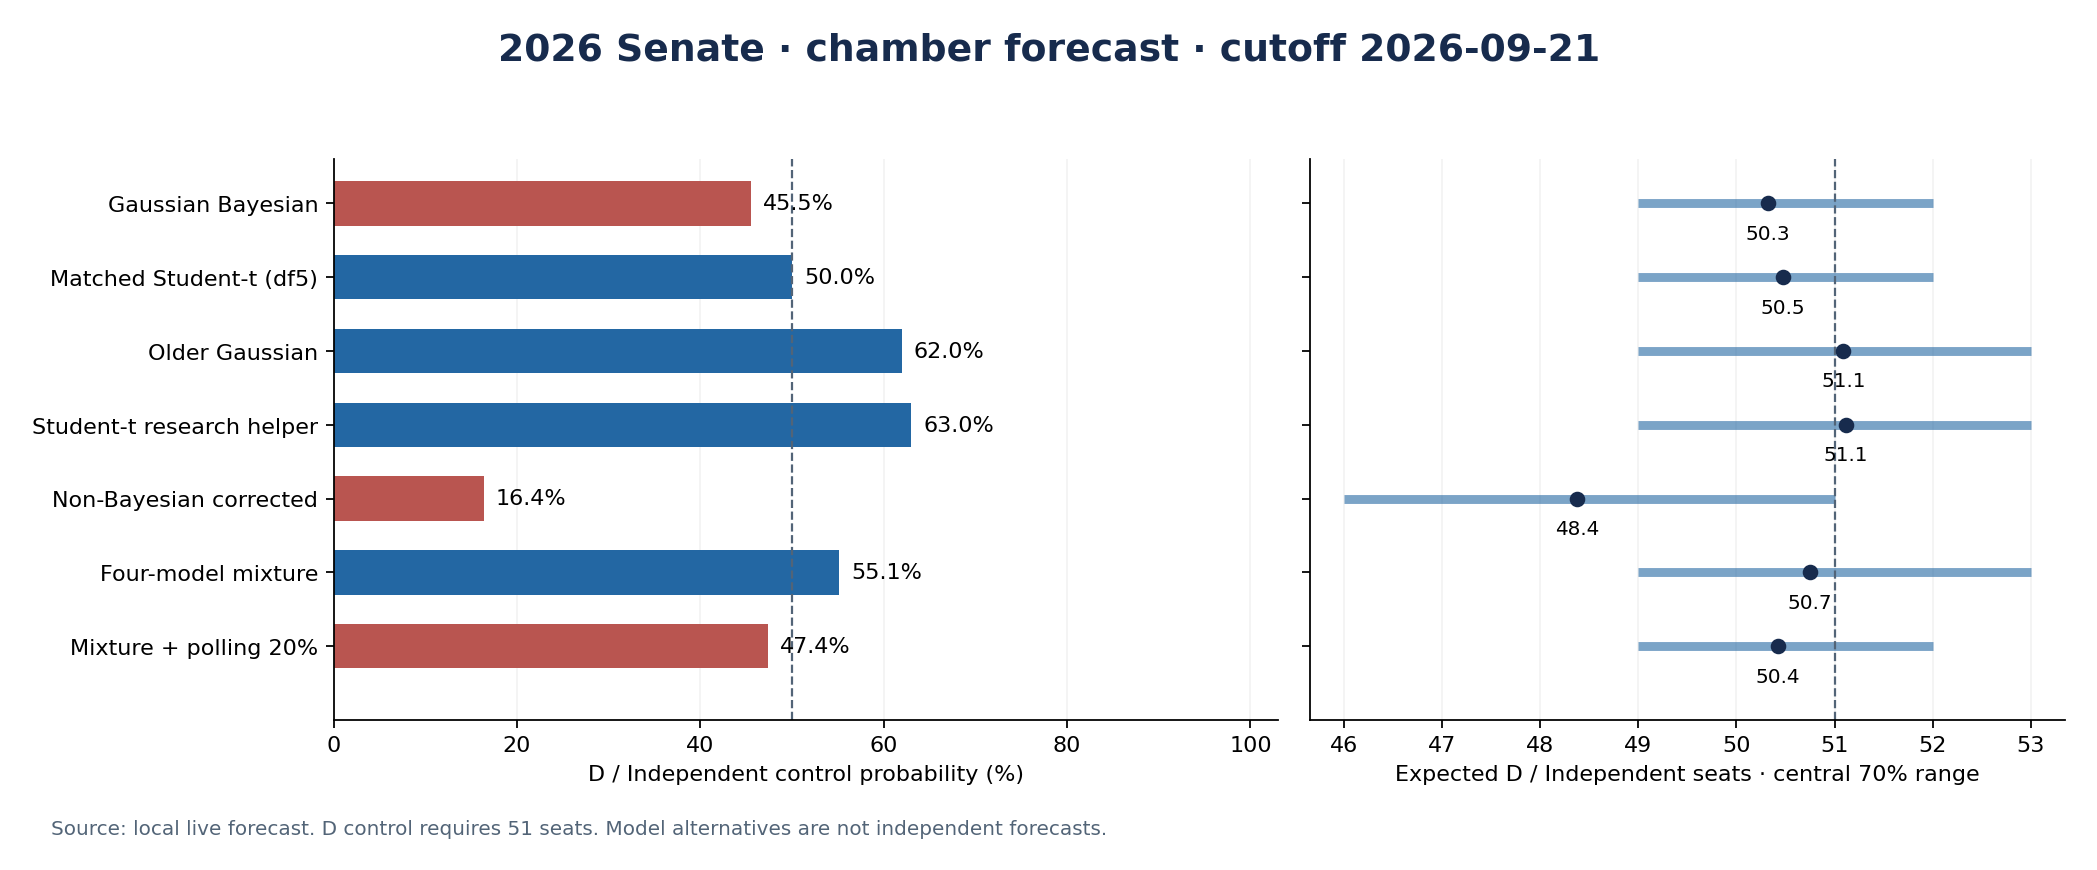

In [5]:
tables=lab.display_tables(RUN)
DISPLAY_MODELS=['Bayesian','Matched Student-t (df5)','Older Gaussian','Student-t research helper','Non-Bayesian corrected','Four-model mixture','Mixture + polling 20%']
seats=tables['seats'].set_index('model').reindex([m for m in DISPLAY_MODELS if m in tables['seats'].model.values]).reset_index()
seats['D control %']=100*seats.p_D_control
display(seats[['model','point_D','point_R','expected_D','D control %','D_lo70','D_hi70']].round(3))
display_images(chamber_images(seats, SHARE_DIR, meta['as_of']))


## 4. State margins and probabilities

Positive D−R margins favor Democrats. Unpolled states remain in the model; their estimates rely on priors and cross-state information. Blend percentages are sensitivities, not a selected new main forecast.

D−R margins (pp)


model,Gaussian Bayesian,Matched Student-t (df5),Older Gaussian,Student-t research helper,Non-Bayesian corrected,Four-model mixture,Mixture + polling 20%
State,,,,,,,
AK,-3.10,-2.87,-0.77,-0.86,-2.17,-1.90,-1.95
AL,-22.02,-21.94,-18.24,-18.62,-21.69,-20.21,-20.50
AR,-20.80,-19.23,-12.03,-11.70,-23.32,-15.94,-17.42
CO,17.44,17.62,14.13,14.40,5.95,15.90,13.91
DE,24.95,25.15,25.61,25.88,15.52,25.40,23.42
FL (special),-5.48,-5.32,-4.16,-4.14,-9.12,-4.78,-5.65
GA,5.22,5.31,5.94,5.90,3.39,5.59,5.15
IA,-3.27,-3.08,-2.80,-2.80,-5.46,-2.99,-3.48
ID,-25.97,-25.75,-27.04,-26.77,-29.76,-26.38,-27.06


Democratic win probabilities (%)


model,Gaussian Bayesian,Matched Student-t (df5),Older Gaussian,Student-t research helper,Non-Bayesian corrected,Four-model mixture,Mixture + polling 20%
State,,,,,,,
AK,30.0,27.5,45.9,44.3,43.1,37.0,36.7
AL,0.0,0.1,3.3,1.9,4.2,1.3,1.2
AR,0.2,0.8,14.4,9.5,3.1,6.3,4.8
CO,92.7,94.3,85.5,88.8,68.2,90.3,87.5
DE,99.9,99.6,99.3,98.9,89.2,99.4,99.2
FL (special),20.3,15.1,31.8,26.7,23.3,23.7,20.0
GA,80.8,86.4,78.3,83.6,60.7,82.1,80.1
IA,29.2,25.8,34.0,29.6,33.2,29.4,26.5
ID,0.0,0.3,0.1,0.5,0.9,0.2,0.2


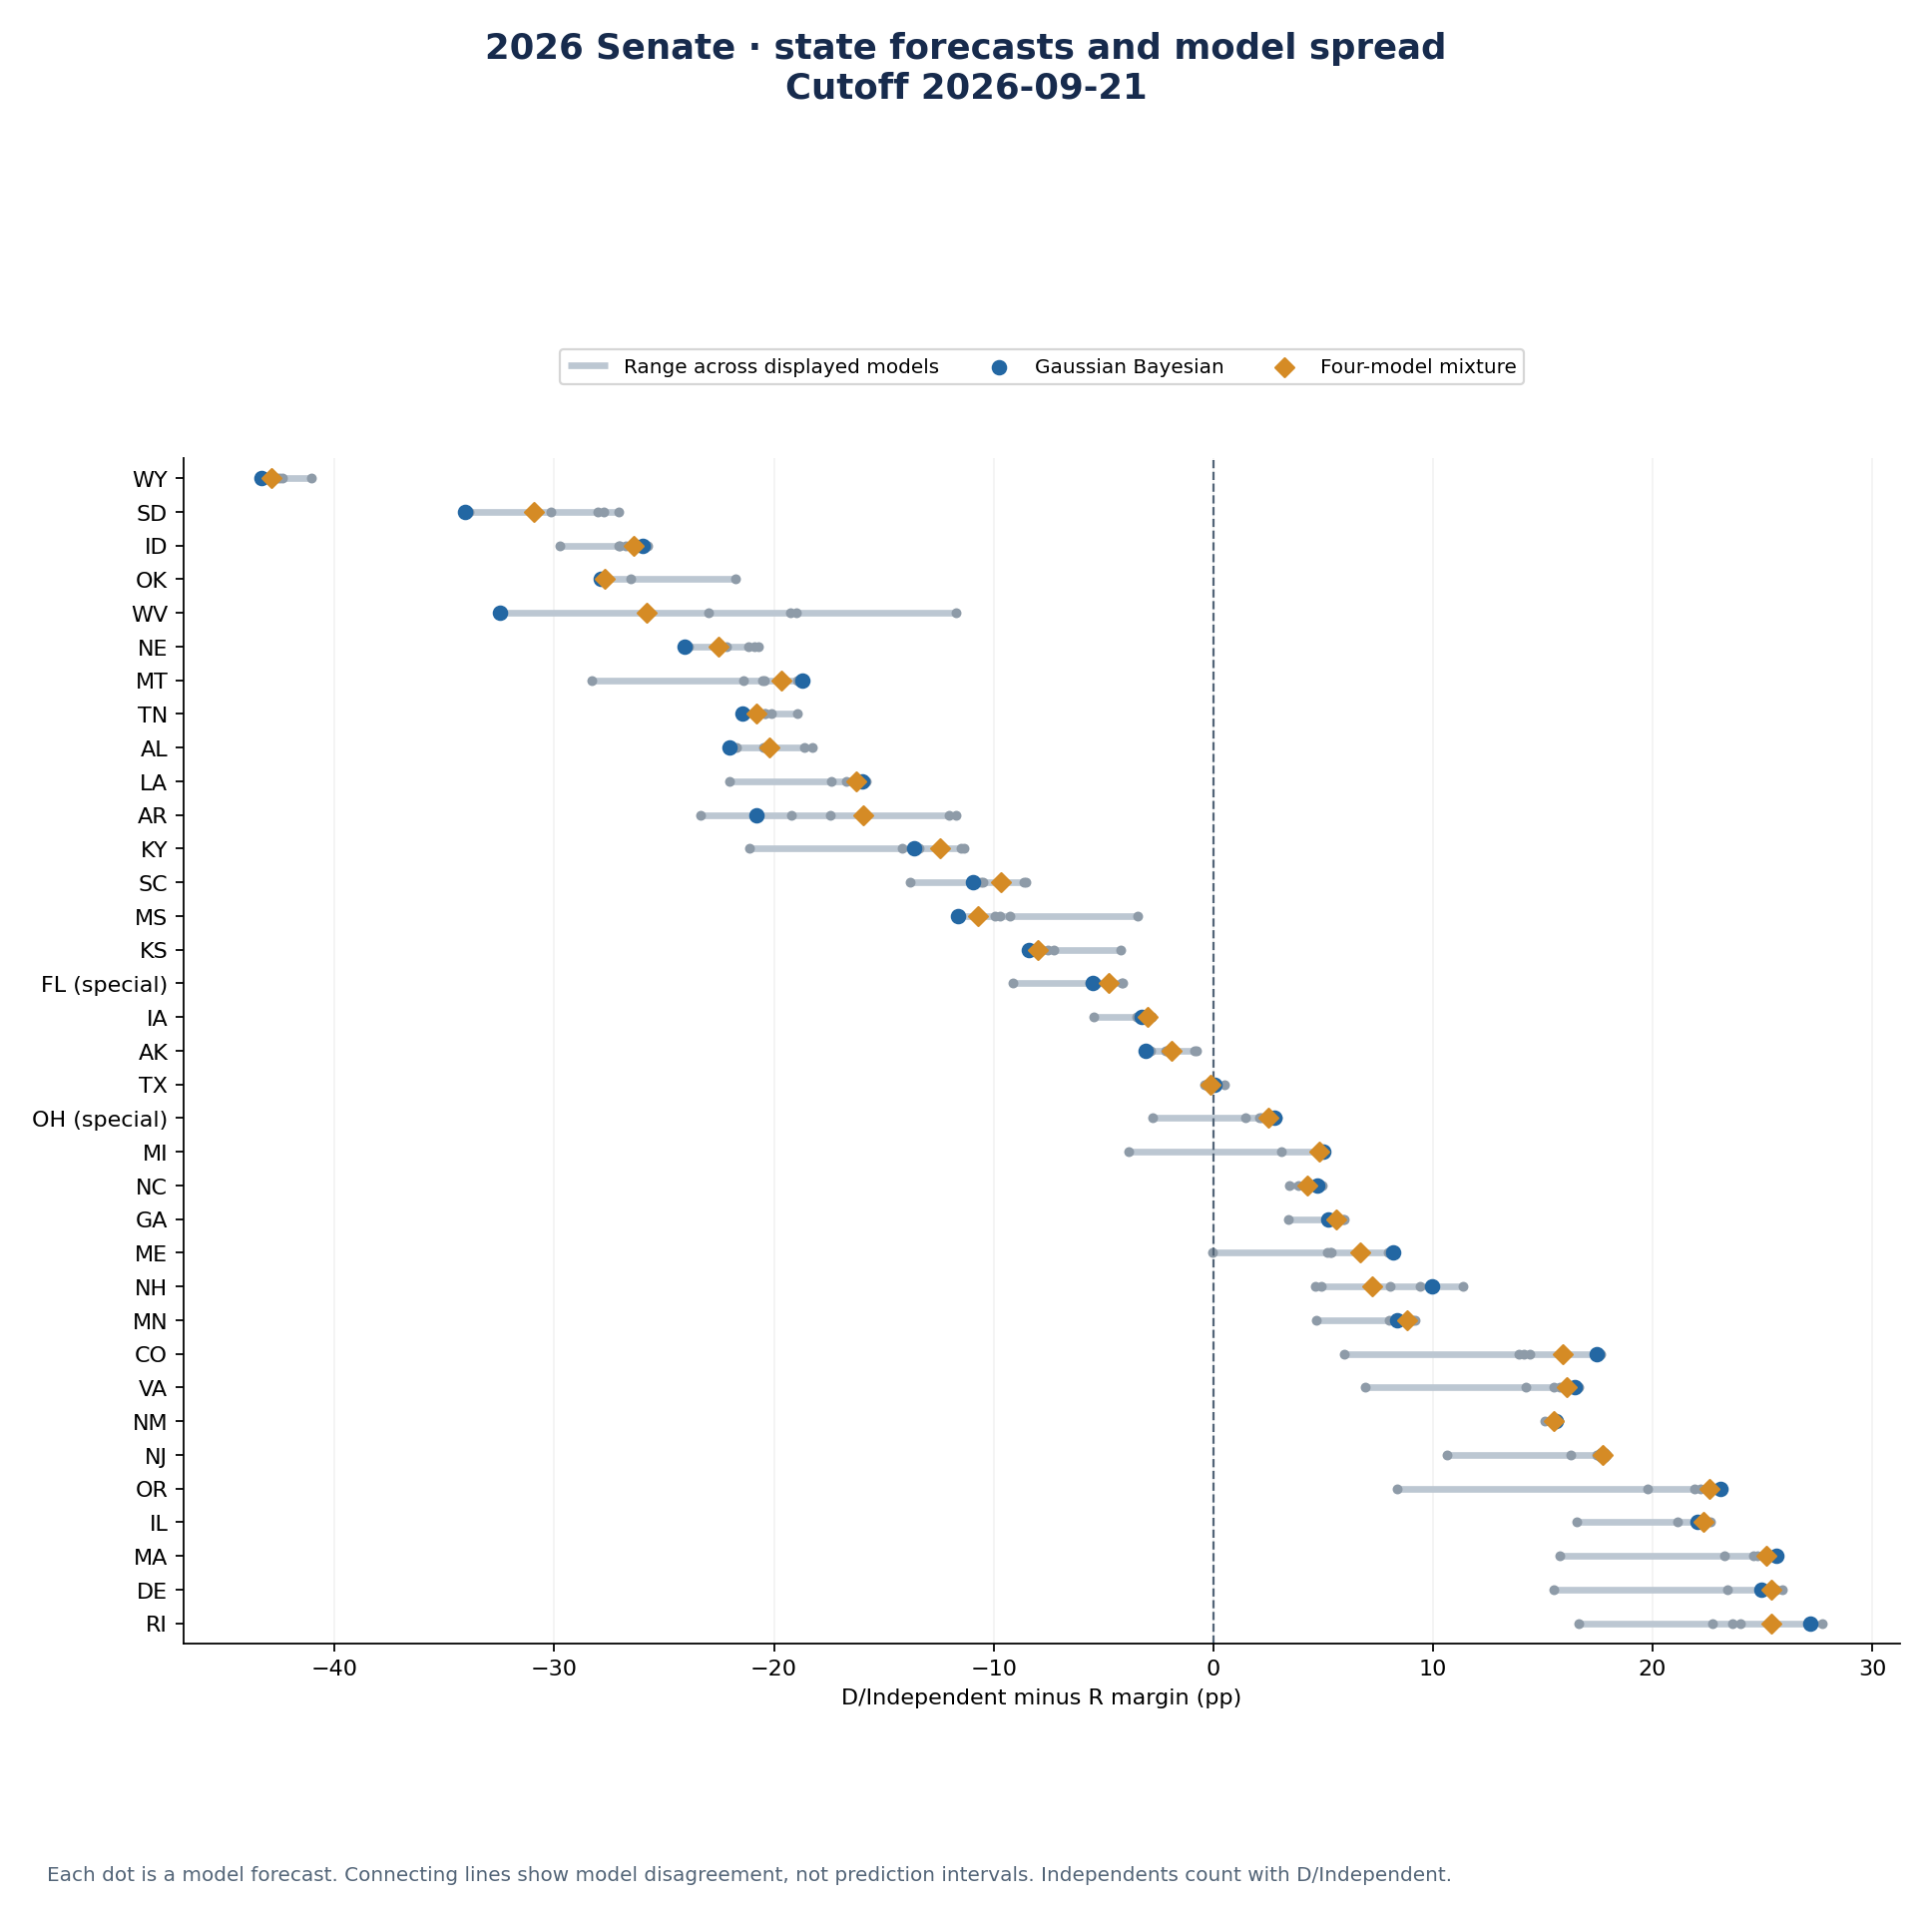

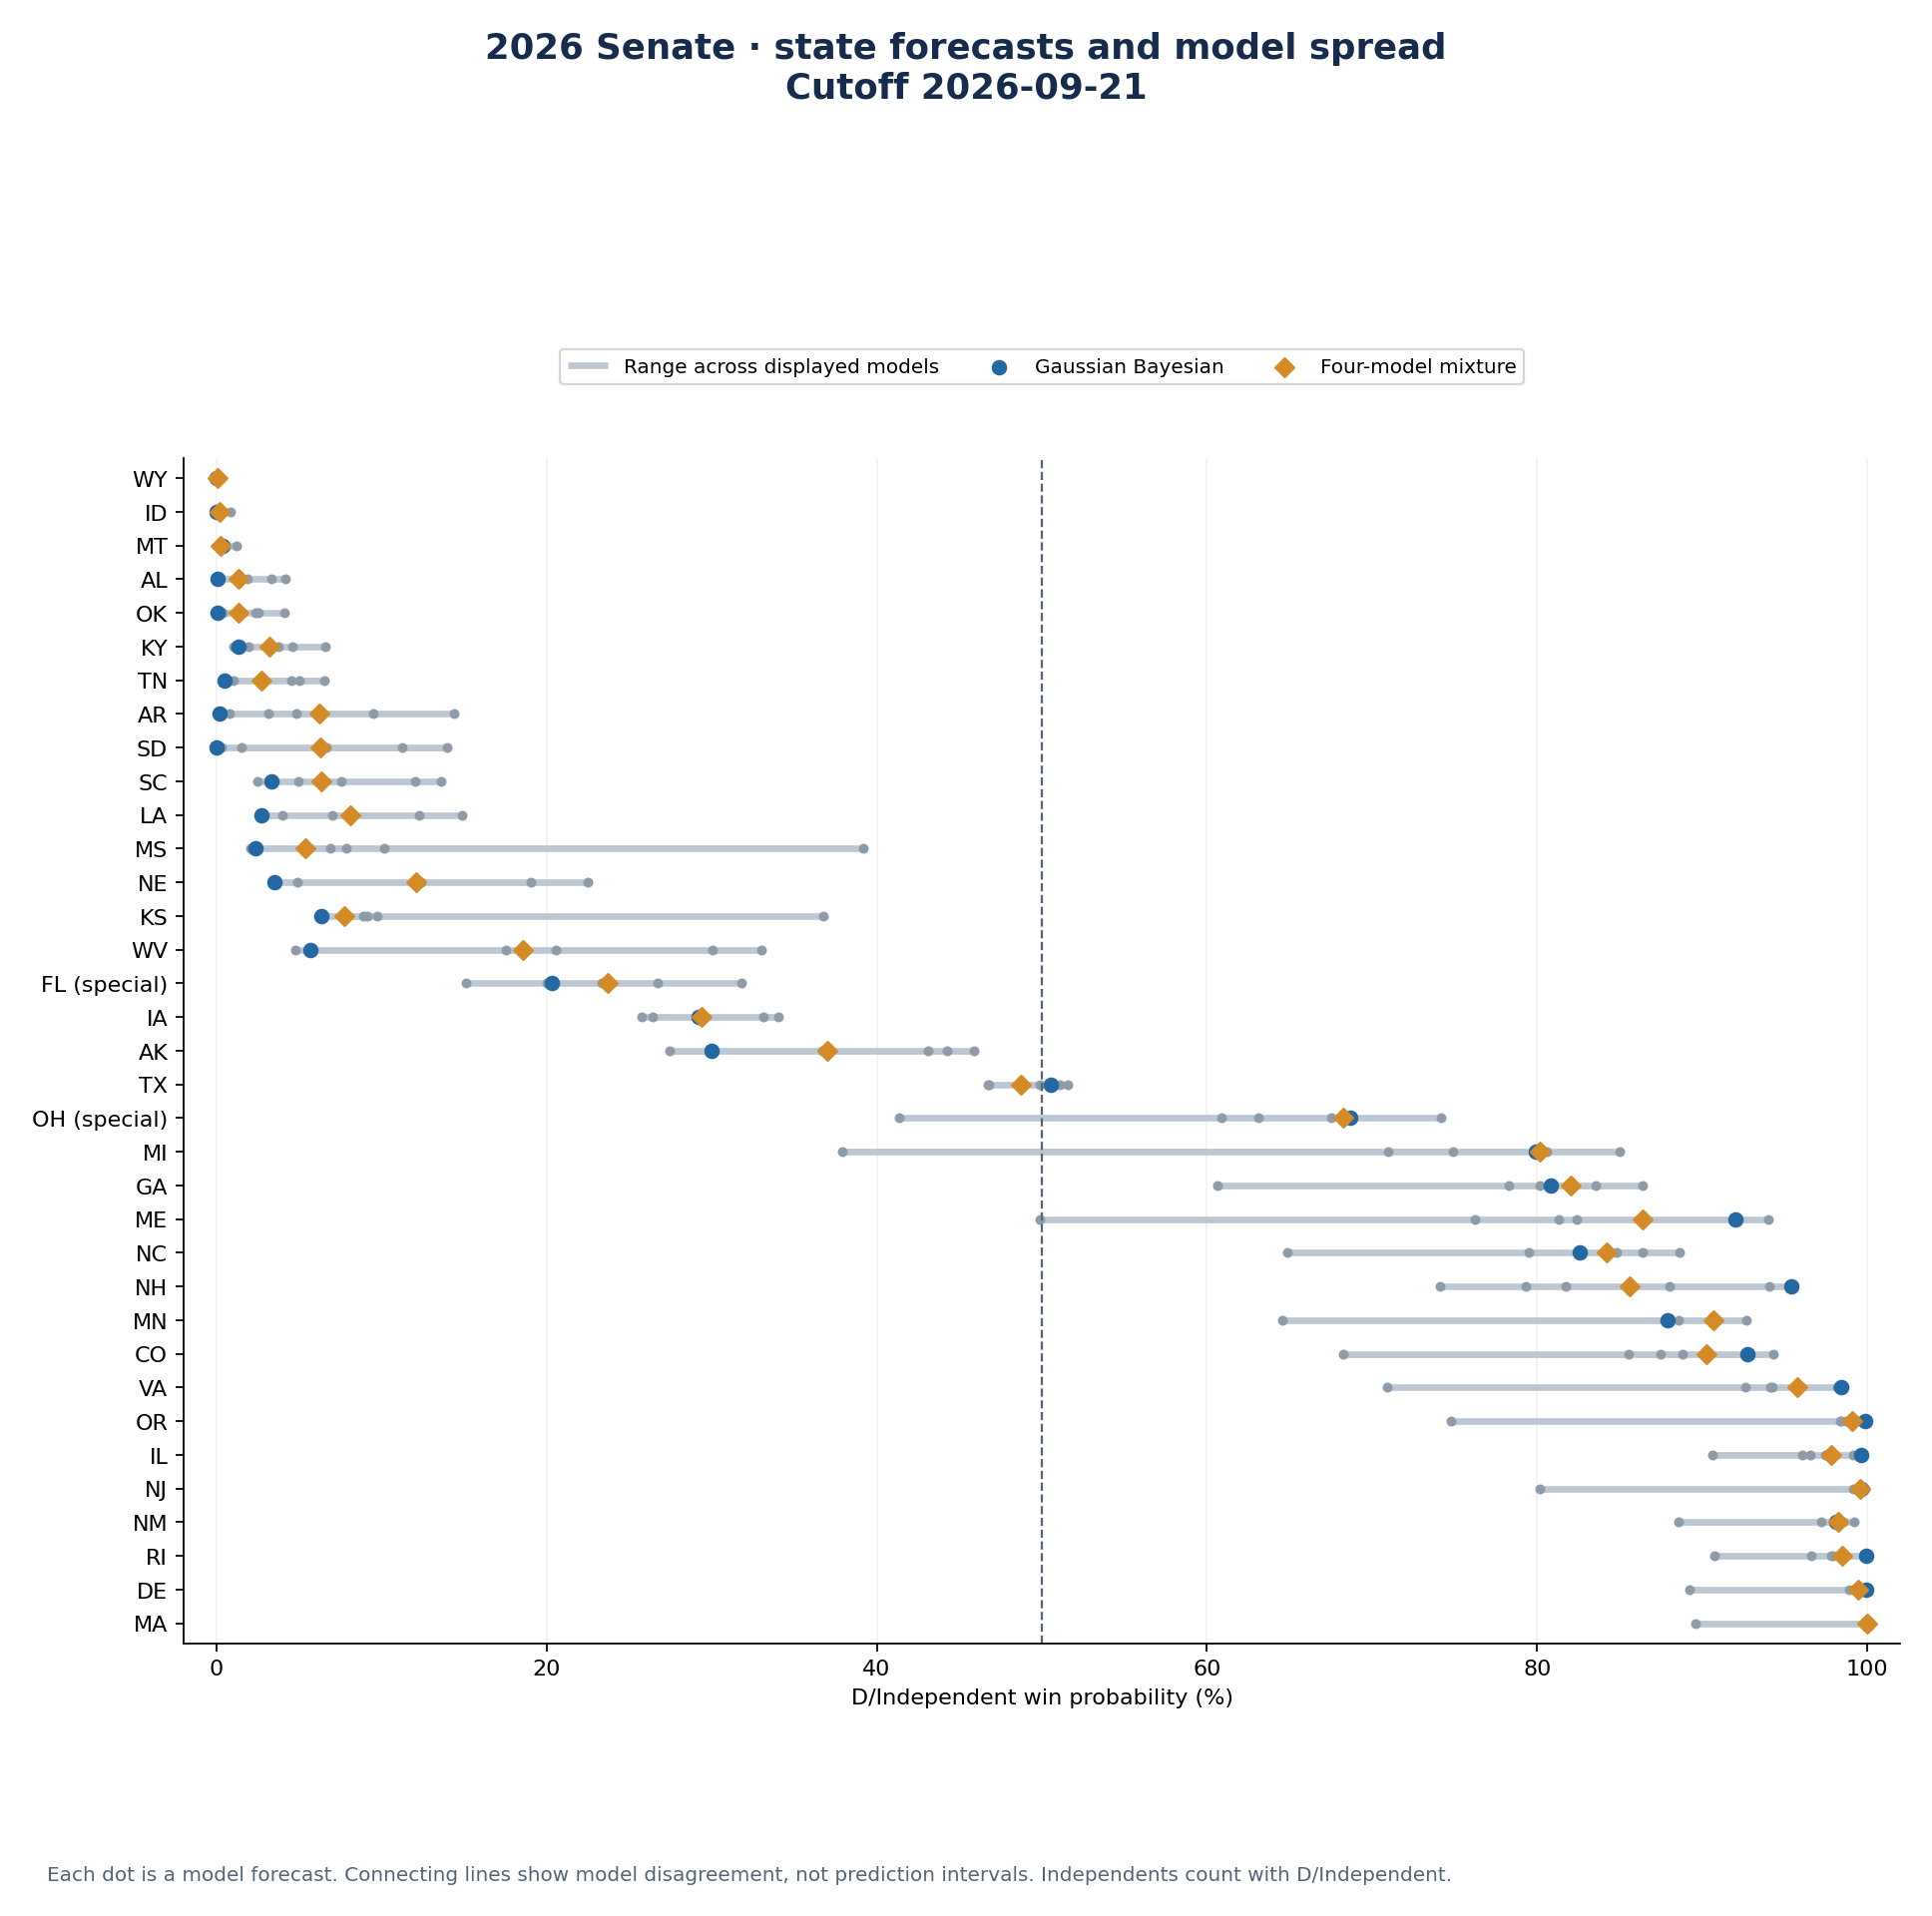

In [6]:
print('D−R margins (pp)')
show=[m for m in DISPLAY_MODELS if m in tables['margins'].columns]
display(tables['margins'][show].round(2))
print('Democratic win probabilities (%)')
display(tables['probabilities'][show].round(1))
display_images(state_images(tables, show, SHARE_DIR, meta['as_of']))


## 5. Wide uncertainty despite recent polling

This watchlist ranks **uncertainty in the margin**, not closeness to a 50/50 win probability. It uses this run's cutoff and dataset, so Run All automatically updates the list after refreshing data.

Defaults: an eligible poll ending within **30 days** (age 0–30 inclusive), and a **95% interval at least 25 percentage points wide**. A stronger-coverage flag requires **3 distinct recent samples from at least 2 identified firms**. These adjustable thresholds are descriptive, not learned. Dates are field-end dates; unknown publication dates retain the forecast's existing screening policy. Multiple question versions from the same sample count once.

The first table shows qualifying states under the main Gaussian. The second applies the same filter to every displayed model. `watchlist['recent']` retains all recently polled states and models, including those below the width threshold; `watchlist['broad']` contains all qualifying rows. Positive margins mean D−R in percentage points.

Missing polls can leave broad priors; one recent poll does not eliminate sparse-evidence uncertainty. Wide intervals alone do **not** establish fat tails or a likely political shock. The non-Bayesian helper has a common error spread across states, and mean-only blends preserve their base distribution's centered uncertainty. Student intervals use saved sampled quantiles, not a Gaussian approximation.


As of 2026-09-21: recent = age 0–30 days; broad = 95% interval width ≥ 25 pp
Stronger coverage = ≥3 samples from ≥2 firms.


,latest_poll,recent_samples,recent_firms,stronger_coverage,prediction_pp,lo95_pp,hi95_pp,width95_pp
contest,,,,,,,,
NM,2026-08-28,1,1,False,15.6,0.9,30.3,29.4
MN,2026-09-10,1,1,False,8.4,-5.7,22.4,28.1
MT,2026-09-15,3,3,True,-18.7,-32.3,-5.0,27.3
FL special,2026-09-17,3,3,True,-5.5,-18.4,7.4,25.8


,recent_contests,broad_contests,states,stronger_coverage_states
model,,,,
Gaussian Bayesian,17,4,"NM, MN, MT, FL special","MT, FL special"
Matched Student-t (df5),17,2,"NM, MN",None
Older Gaussian,17,13,"FL special, NM, KY, GA, AK, MT, SC, ME, NH, MI, MN, IA, MA","FL special, AK, MT, SC, ME, MI, IA"
Student-t research helper,17,3,"NM, FL special, KY",FL special
Non-Bayesian corrected,17,17,"AK, FL special, GA, IA, KS, KY, MA, ME, MI, MN, MT, NC, NH, NM, OH special, SC, TX","AK, FL special, IA, ME, MI, MT, NC, OH special, SC, TX"
Four-model mixture,17,7,"NM, FL special, NH, MT, MN, KY, AK","FL special, MT, AK"
Mixture + polling 20%,17,7,"NM, FL special, NH, MT, MN, KY, AK","FL special, MT, AK"


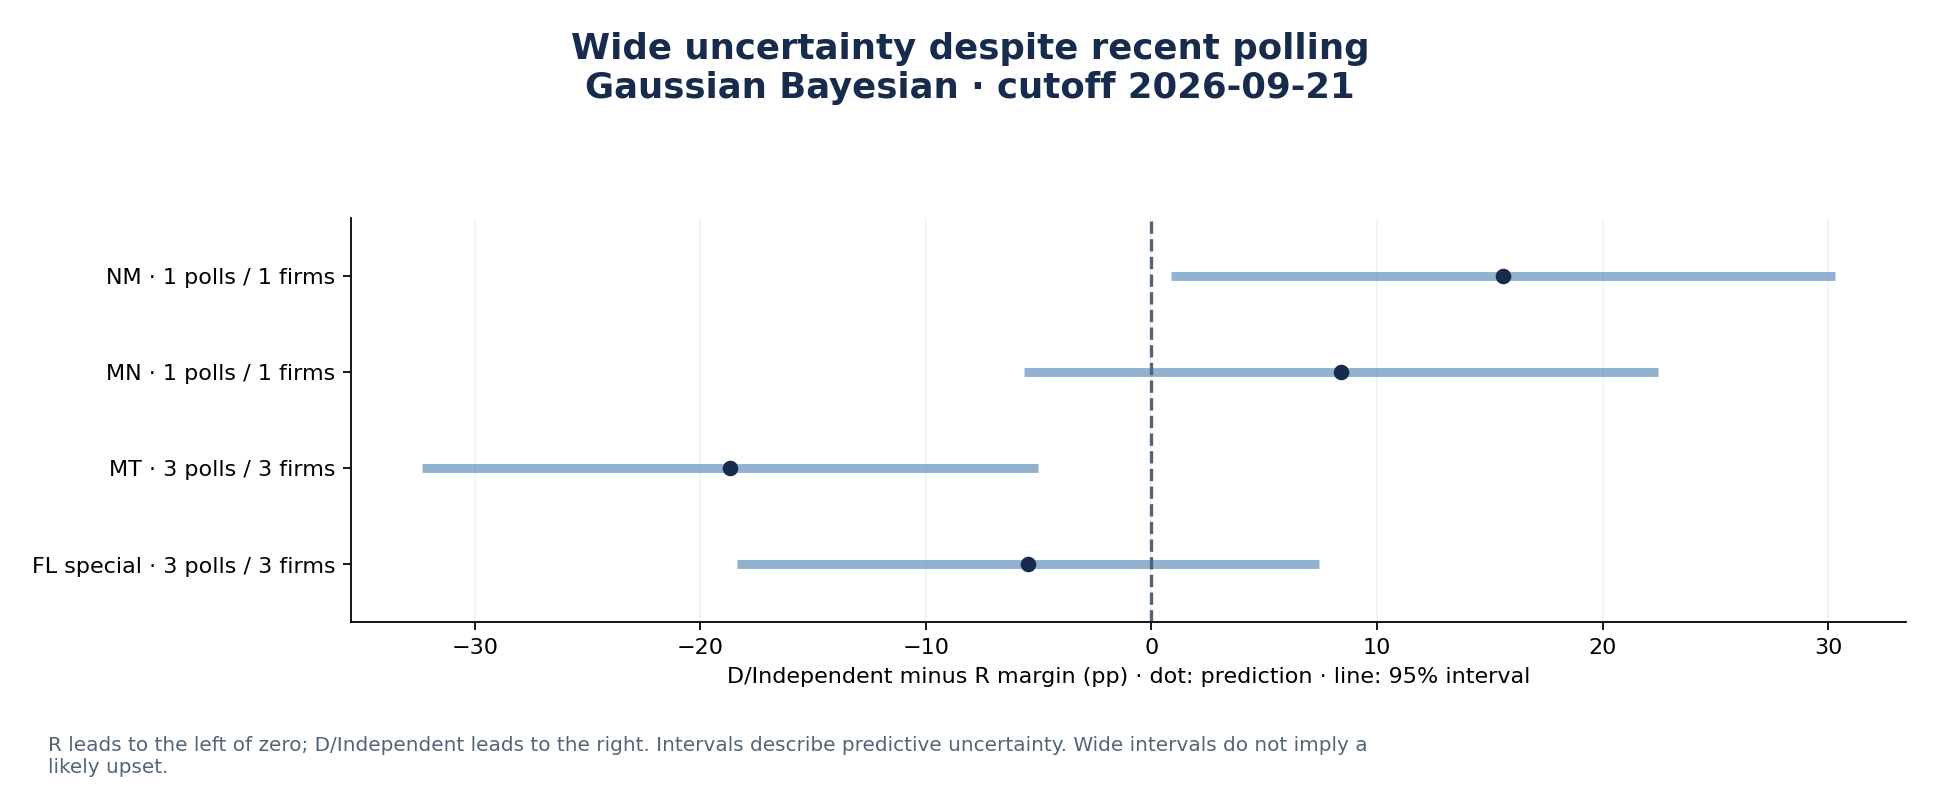

In [7]:
from live_uncertainty_watchlist import build_watchlist

RECENT_DAYS = 30
MIN_95_WIDTH_PP = 25.0
MIN_RECENT_SAMPLES = 3
MIN_RECENT_FIRMS = 2

watchlist = build_watchlist(
    RUN, DISPLAY_MODELS, recent_days=RECENT_DAYS, min_width_pp=MIN_95_WIDTH_PP,
    min_samples=MIN_RECENT_SAMPLES, min_firms=MIN_RECENT_FIRMS,
)
print(f"As of {watchlist['as_of']}: recent = age 0–{RECENT_DAYS} days; "
      f"broad = 95% interval width ≥ {MIN_95_WIDTH_PP:g} pp")
print(f"Stronger coverage = ≥{MIN_RECENT_SAMPLES} samples from ≥{MIN_RECENT_FIRMS} firms.")
main_watch = watchlist['broad'].query("model == 'Bayesian'")
if main_watch.empty:
    print('No main-model states meet both the recency and width filters.')
else:
    display(main_watch[['contest', 'latest_poll', 'recent_samples', 'recent_firms',
                        'stronger_coverage', 'prediction_pp', 'lo95_pp', 'hi95_pp',
                        'width95_pp']].set_index('contest').round(1))
with pd.option_context('display.max_colwidth', None):
    display(watchlist['summary'].set_index('model'))

display_images(uncertainty_images(main_watch, SHARE_DIR, meta['as_of']))


## 5b. Races to watch: likely outcome and room for a surprise

Two tables separate adequate polling from thin/no recent polling. Each lists the likely winner, reference-model margin and 95% range, probability the other party wins, average core-model disagreement, and predictive standard deviation. Zero-recent-poll races remain eligible.

Within each group, we take the union of the top three races for disagreement, predictive uncertainty, other-winner probability, and historical mean absolute error (requiring at least two past races). Reasons explain each selection; this is a descriptive screen, not an estimated probability of surprising the public. Historical context uses up to three past **state** races in September backtests (not necessarily the same Senate seat), excluding the current cycle. Past misses do not change current forecasts.

Reference-model winner, margin, 95% interval and other-winner probability describe the likely outcome and its alternatives. Disagreement is the mean absolute pairwise difference in core-model margins. Predictive SD is the square root of the mean within-model variance, not variance between model means. Blends/mixtures are excluded; the core models share evidence and are not independent votes. Within each polling group, select the top 3 races on each of disagreement, predictive SD, reference-model other-winner probability, and historical mean absolute error (at least two past races); take their union and order by other-winner probability. Ties are broken by contest name. This is a review screen, not a calibrated probability of surprising the public. History uses the last three completed state races in September backtests before the current cycle; it can include other Senate seats and special elections. These are reconstructed forecasts, not issued forecasts. Past errors are context and do not alter current probabilities.

Forecast cutoff: 2026-09-21
Core models: Gaussian Bayesian, Matched Student-t (df5), Older Gaussian, Student-t research helper, Non-Bayesian corrected


### Adequately polled races

Race,Likely winner,D−R margin,95% range (pp),Other winner %,Disagreement (pp),Predictive SD (pp),Recent polls / firms,Past state surprises,Why watch
TX,D,0.1,-9.5 to 9.6,49.5,0.5,7.0,9 / 9,The largest miss was 5.1 pp in 2018. 0 of 3 results fell outside the 95% range. It missed the winner in 0 of 3 races.,Other-winner probability ranks #1 in this group. Models disagree on the winner.
OH special,D,2.8,-8.4 to 13.9,31.3,2.4,7.4,3 / 3,The largest miss was 5.9 pp in 2022. 0 of 3 results fell outside the 95% range. It missed the winner in 0 of 3 races.,Other-winner probability ranks #2 in this group. Models disagree on the winner.
AK,R,-3.1,-14.7 to 8.5,30.0,1.3,7.9,3 / 3,No comparable history is available.,Predictive uncertainty ranks #3 in this group. Other-winner probability ranks #3 in this group.
IA,R,-3.3,-14.9 to 8.4,29.2,1.2,7.6,9 / 9,The largest miss was 10.4 pp in 2016. 0 of 3 results fell outside the 95% range. It missed the winner in 0 of 3 races.,Past margin error ranks #3 in this group.
FL special,R,-5.5,-18.4 to 7.4,20.3,2.3,8.4,3 / 3,The largest miss was 12.4 pp in 2022. 1 of 3 results fell outside the 95% range. It missed the winner in 0 of 3 races.,Predictive uncertainty ranks #1 in this group. Past margin error ranks #2 in this group. 1 of 3 past results fell outside the 95% range.
MI,D,5.0,-6.7 to 16.7,20.1,3.6,7.7,8 / 8,The largest miss was 11.9 pp in 2018. 0 of 3 results fell outside the 95% range. It missed the winner in 0 of 3 races.,Model disagreement ranks #3 in this group. Past margin error ranks #1 in this group. Models disagree on the winner.
ME,D,8.2,-3.2 to 19.6,8.0,3.8,7.8,4 / 4,No comparable history is available.,Model disagreement ranks #2 in this group. Models disagree on the winner.
MT,R,-18.7,-32.3 to -5.0,0.4,4.2,8.2,3 / 3,The largest miss was 8.8 pp in 2020. 0 of 3 results fell outside the 95% range. It missed the winner in 0 of 3 races.,Model disagreement ranks #1 in this group. Predictive uncertainty ranks #2 in this group.


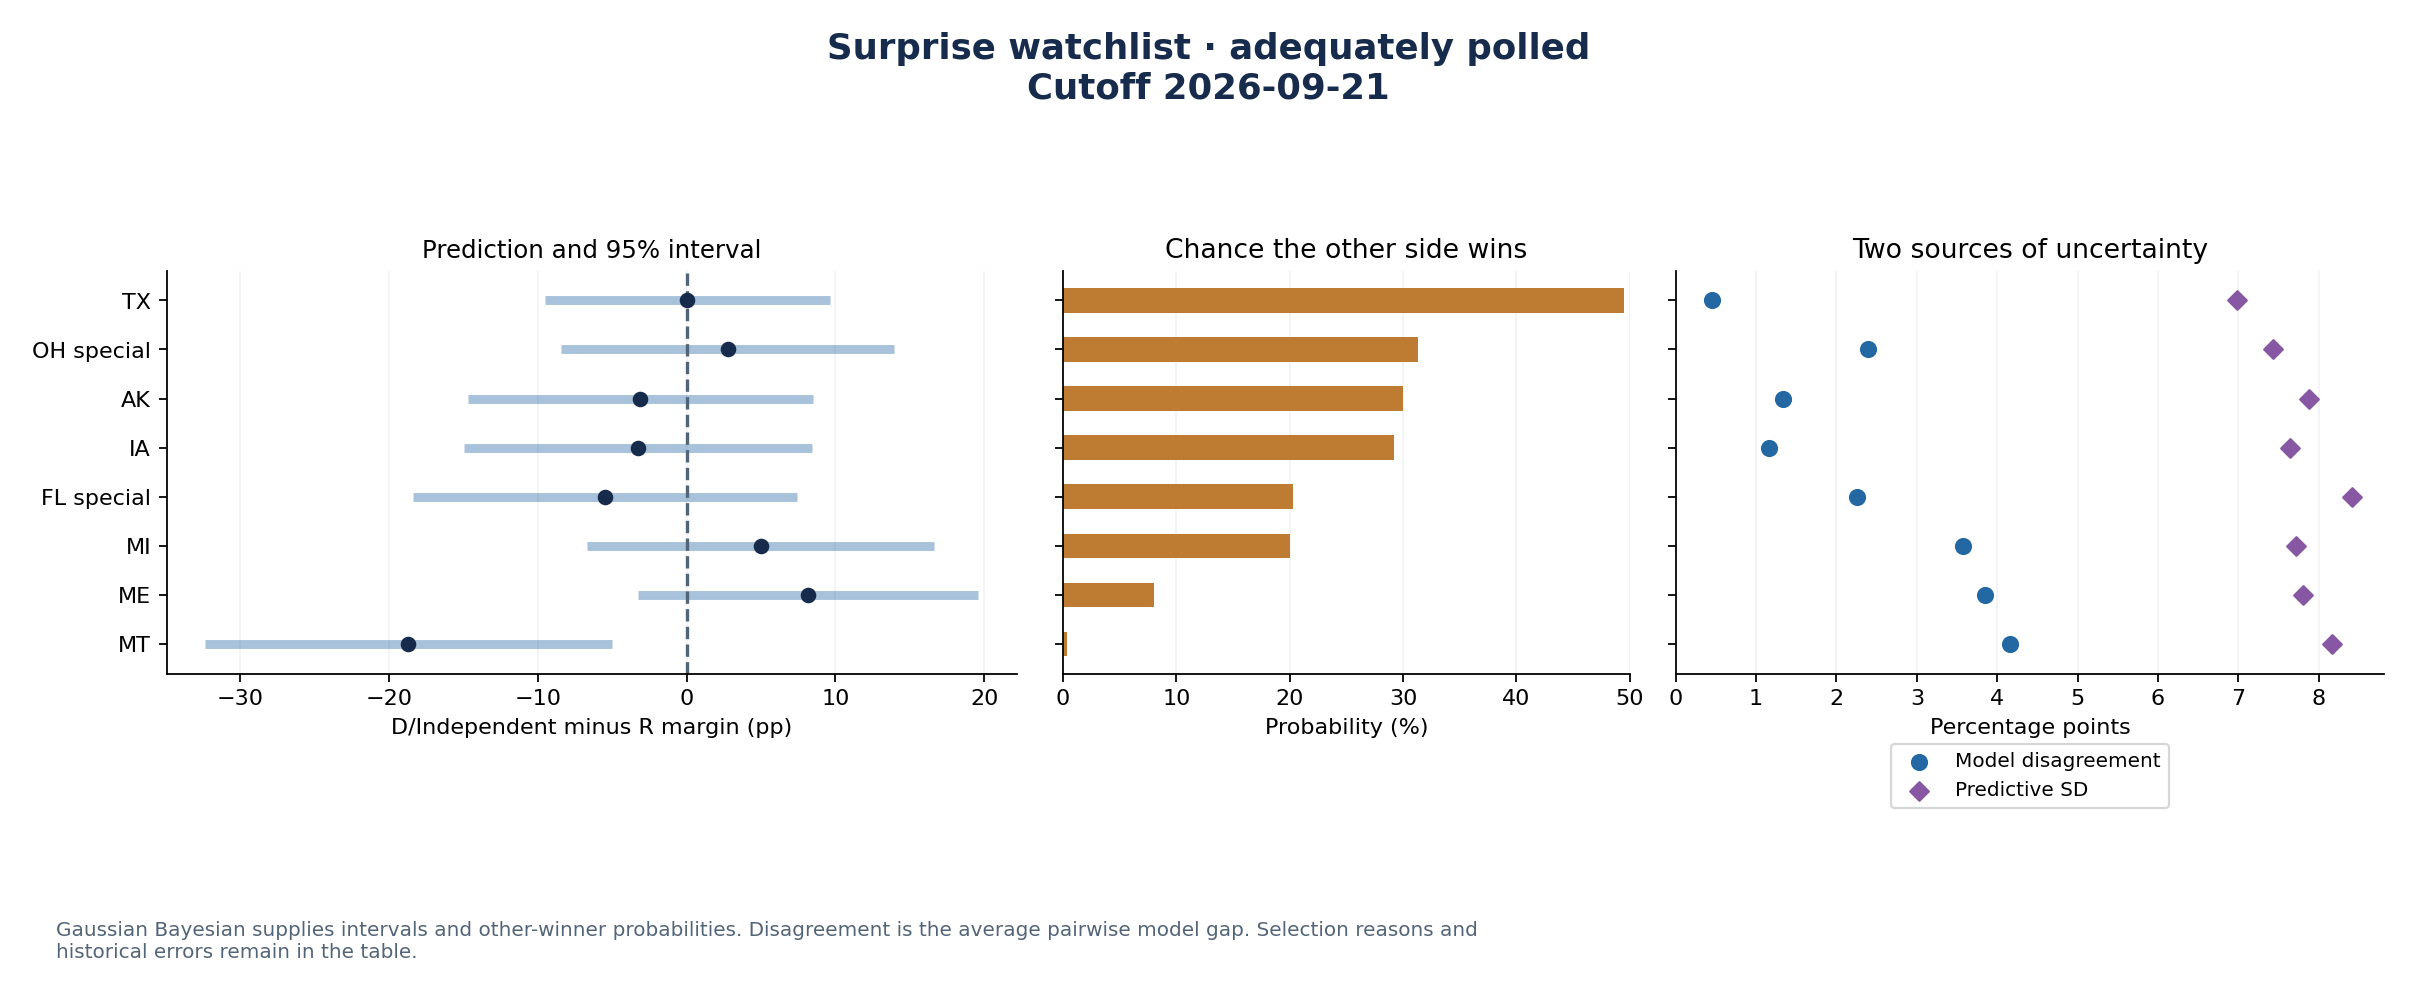

### Thinly polled / no recent polls

Race,Likely winner,D−R margin,95% range (pp),Other winner %,Disagreement (pp),Predictive SD (pp),Recent polls / firms,Past state surprises,Why watch
GA,D,5.2,-6.5 to 16.9,19.2,1.2,7.9,1 / 1,No comparable history is available.,Other-winner probability ranks #1 in this group. Recent polling is limited.
MN,D,8.4,-5.7 to 22.4,12.1,1.9,8.2,1 / 1,The largest miss was 8.9 pp in 2020. 0 of 3 results fell outside the 95% range. It missed the winner in 0 of 3 races.,Other-winner probability ranks #2 in this group. Recent polling is limited.
CO,D,17.4,-6.0 to 40.9,7.3,5.3,12.6,0 / 0,The largest miss was 8.1 pp in 2022. 0 of 3 results fell outside the 95% range. It missed the winner in 0 of 3 races.,Other-winner probability ranks #3 in this group. There are no recent eligible polls.
WV,R,-32.5,-72.7 to 7.7,5.7,11.0,31.1,0 / 0,The largest miss was 47.9 pp in 2020. 1 of 3 results fell outside the 95% range. It missed the winner in 1 of 3 races.,Model disagreement ranks #1 in this group. Predictive uncertainty ranks #1 in this group. Past margin error ranks #2 in this group. There are no recent eligible polls. 1 of 3 past results fell outside the 95% range.
NE,R,-24.1,-50.1 to 2.0,3.5,1.9,20.4,0 / 0,The largest miss was 22.2 pp in 2020. 0 of 3 results fell outside the 95% range. It missed the winner in 0 of 3 races.,Predictive uncertainty ranks #2 in this group. Past margin error ranks #3 in this group. There are no recent eligible polls.
AR,R,-20.8,-34.7 to -6.9,0.2,6.4,9.6,0 / 0,The largest miss was 16.7 pp in 2022. 2 of 3 results fell outside the 95% range. It missed the winner in 0 of 3 races.,Model disagreement ranks #2 in this group. There are no recent eligible polls. 2 of 3 past results fell outside the 95% range.
OR,D,23.1,8.1 to 38.1,0.1,6.1,9.7,0 / 0,The largest miss was 9.7 pp in 2020. 0 of 3 results fell outside the 95% range. It missed the winner in 0 of 3 races.,Model disagreement ranks #3 in this group. There are no recent eligible polls.
SD,R,-34.0,-52.8 to -15.3,<0.1,4.0,18.3,0 / 0,The largest miss was 32.0 pp in 2016. 1 of 3 results fell outside the 95% range. It missed the winner in 0 of 3 races.,Predictive uncertainty ranks #3 in this group. Past margin error ranks #1 in this group. There are no recent eligible polls. 1 of 3 past results fell outside the 95% range.


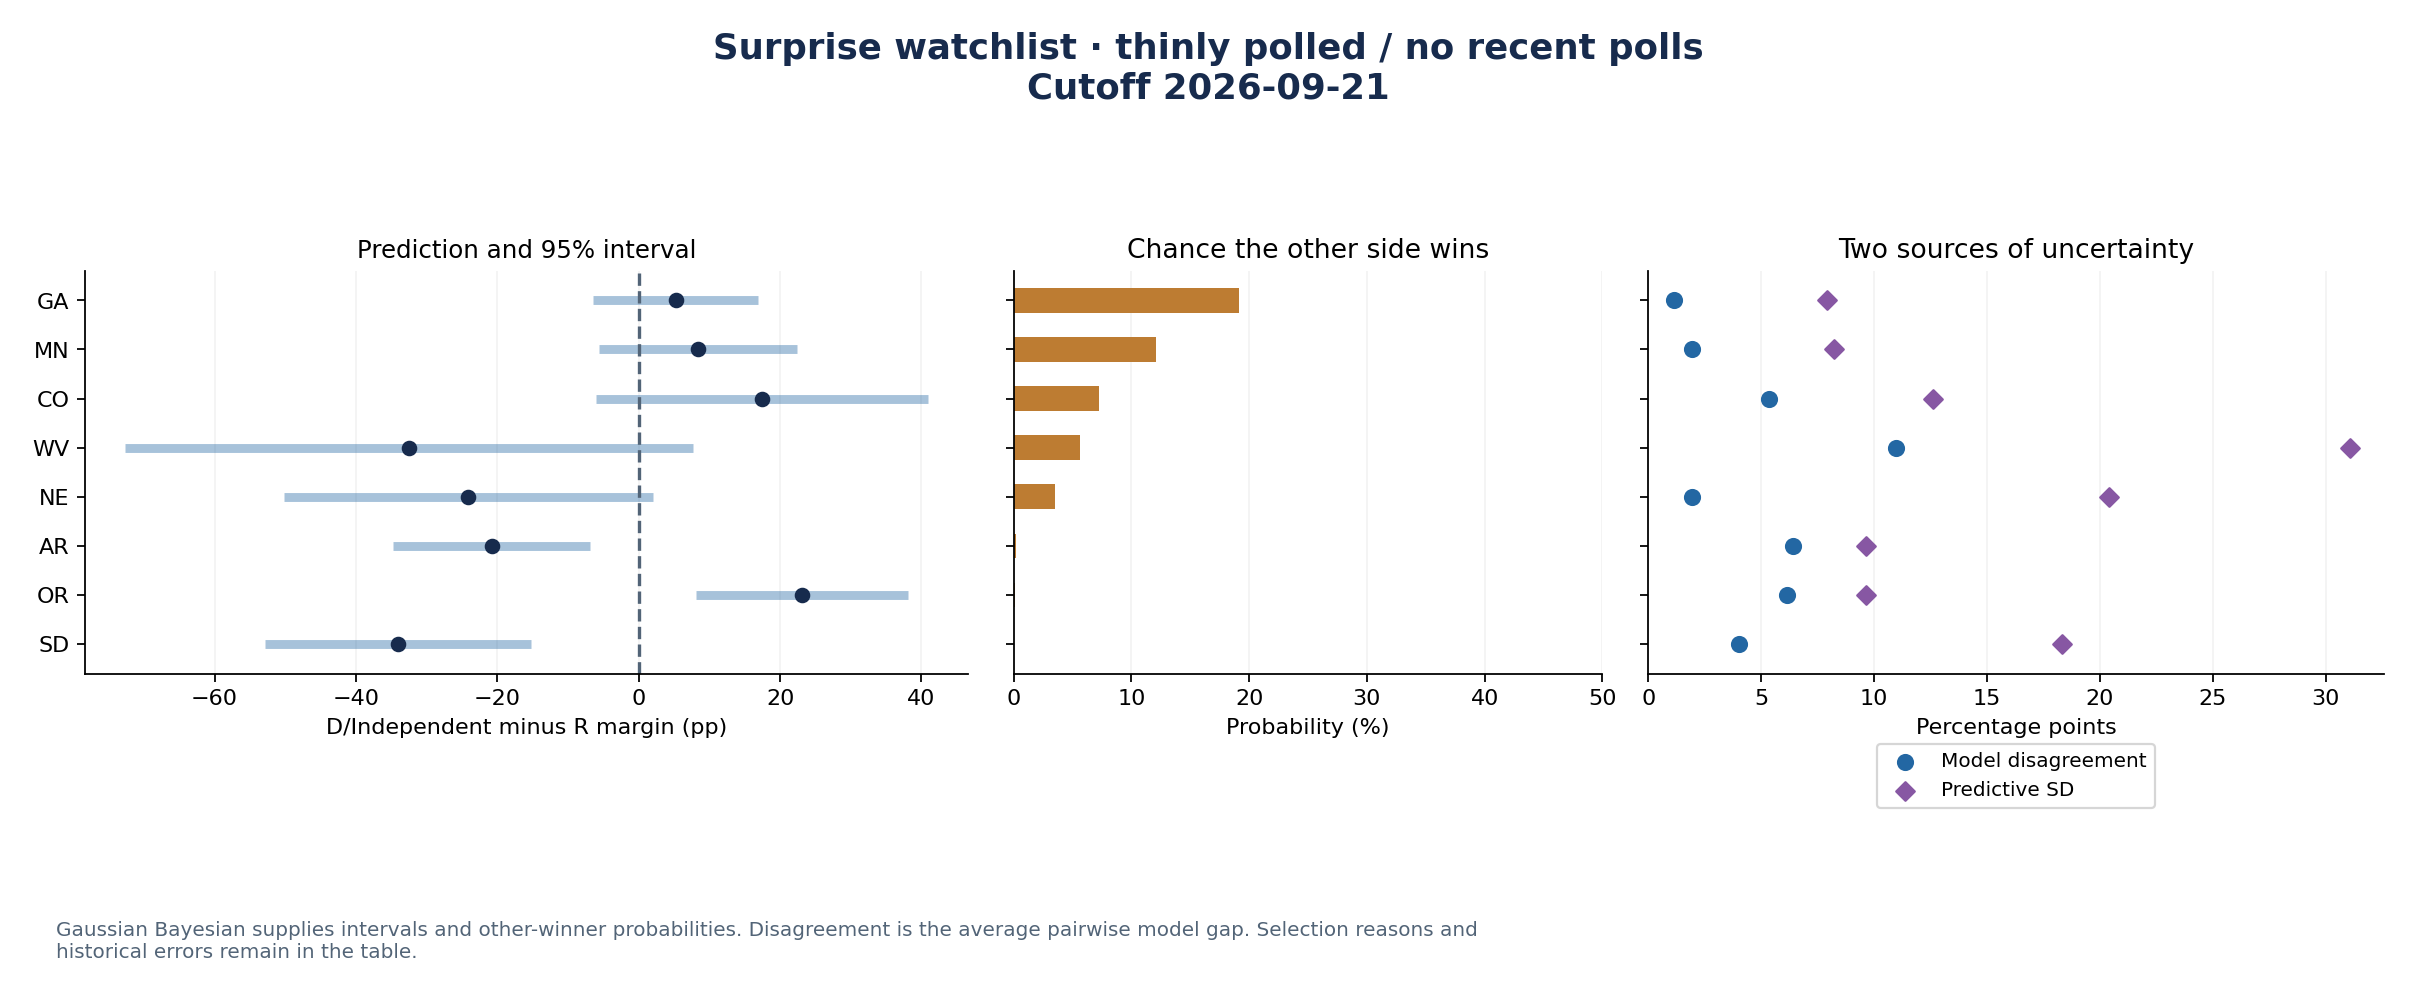

In [8]:
from pathlib import Path
import sys, importlib
from IPython.display import Markdown
from model_labels import display

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'election_lab.py').exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
import election_lab as lab
from model_labels import display, model_label
import live_uncertainty_watchlist
import live_surprise_watchlist
importlib.reload(live_uncertainty_watchlist)
importlib.reload(live_surprise_watchlist)
from live_surprise_watchlist import build_surprise_watchlist, render_table, METHOD

if 'RUN' not in globals():
    RUN = lab.latest_run('live')
surprise = build_surprise_watchlist(
    RUN, recent_days=globals().get('RECENT_DAYS', 30),
    min_samples=globals().get('MIN_RECENT_SAMPLES', 3),
    min_firms=globals().get('MIN_RECENT_FIRMS', 2), top_n=3,
)
display(Markdown(METHOD))
print('Forecast cutoff:', surprise['parameters']['as_of'])
print('Core models:', ', '.join(map(model_label, surprise['parameters']['available_models'])))
for key, title in [('polled', 'Adequately polled races'), ('thin', 'Thinly polled / no recent polls')]:
    display(Markdown('### ' + title))
    display(render_table(surprise[key]))
    display_images(watch_images(surprise[key], key, SHARE_DIR, surprise['parameters']['as_of']))


## 5c. Compare with published forecasts

This cell automatically retrieves Race to the WH probabilities, Inside Elections ratings, and a dated public Silver Bulletin Deluxe Senate-control probability. Silver’s state forecasts and expected seats are not available in the public text. It compares Senate control, expected seats, and state races. It selects different favored winners and large probability gaps using the thresholds below. Full sentences explain each selection. Source dates, unavailable sources, and excluded contests are shown. The same comparison is saved in the report; no text or forecast values need to be entered manually.

Independent candidates count on the D/Independent side for this comparison. Separate D and independent win probabilities are added once. This assumption is recorded in the report.

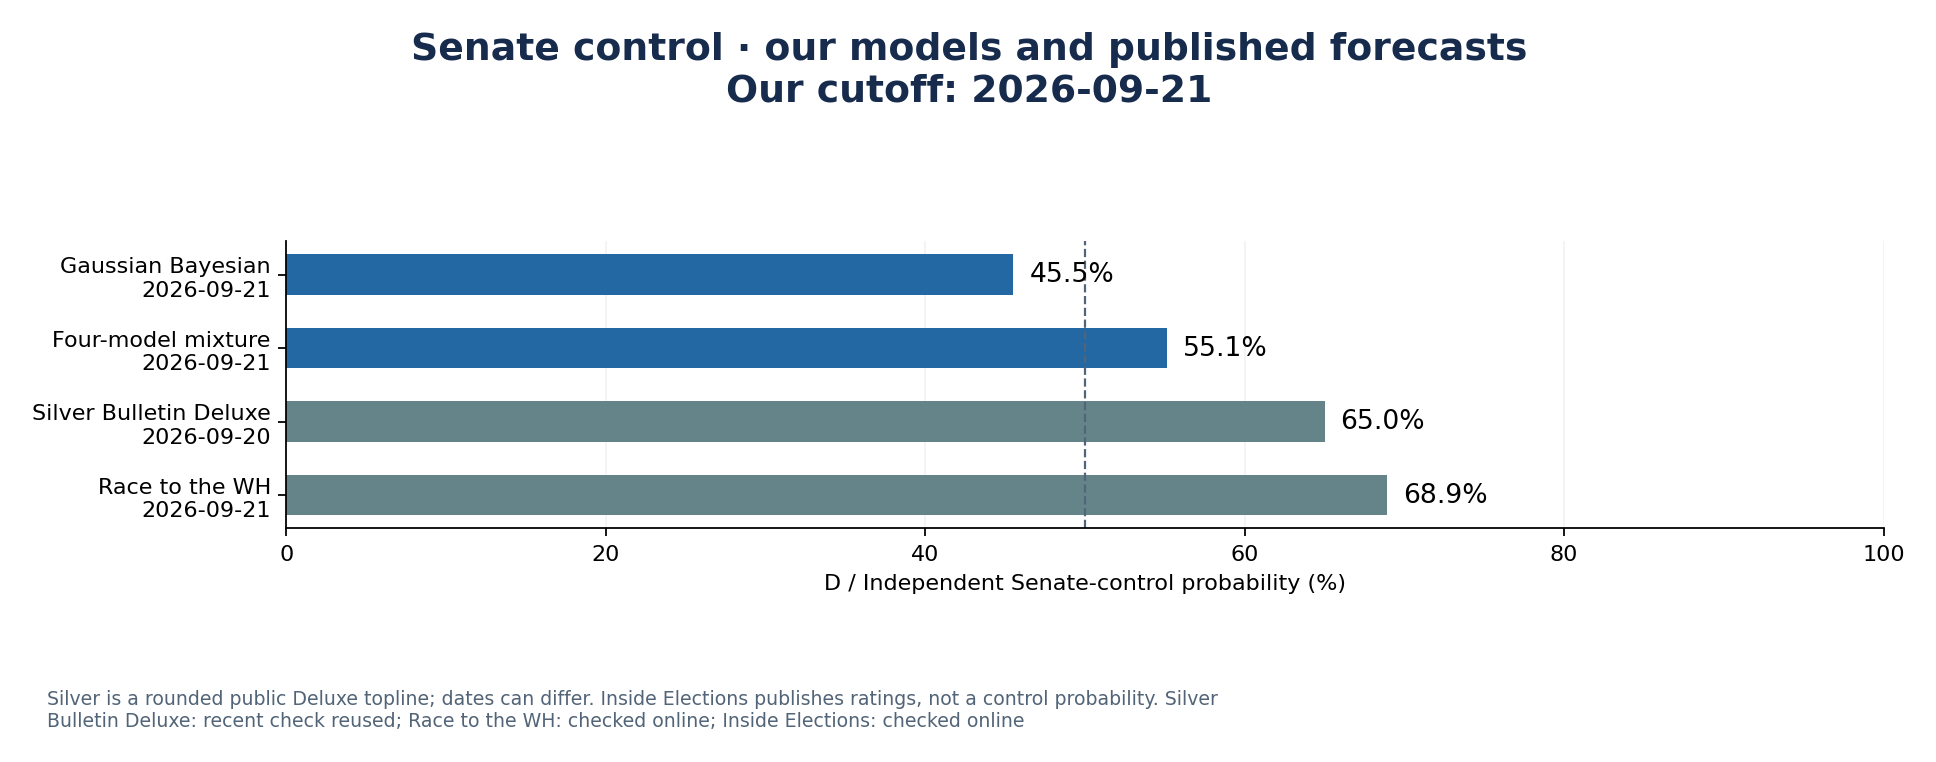

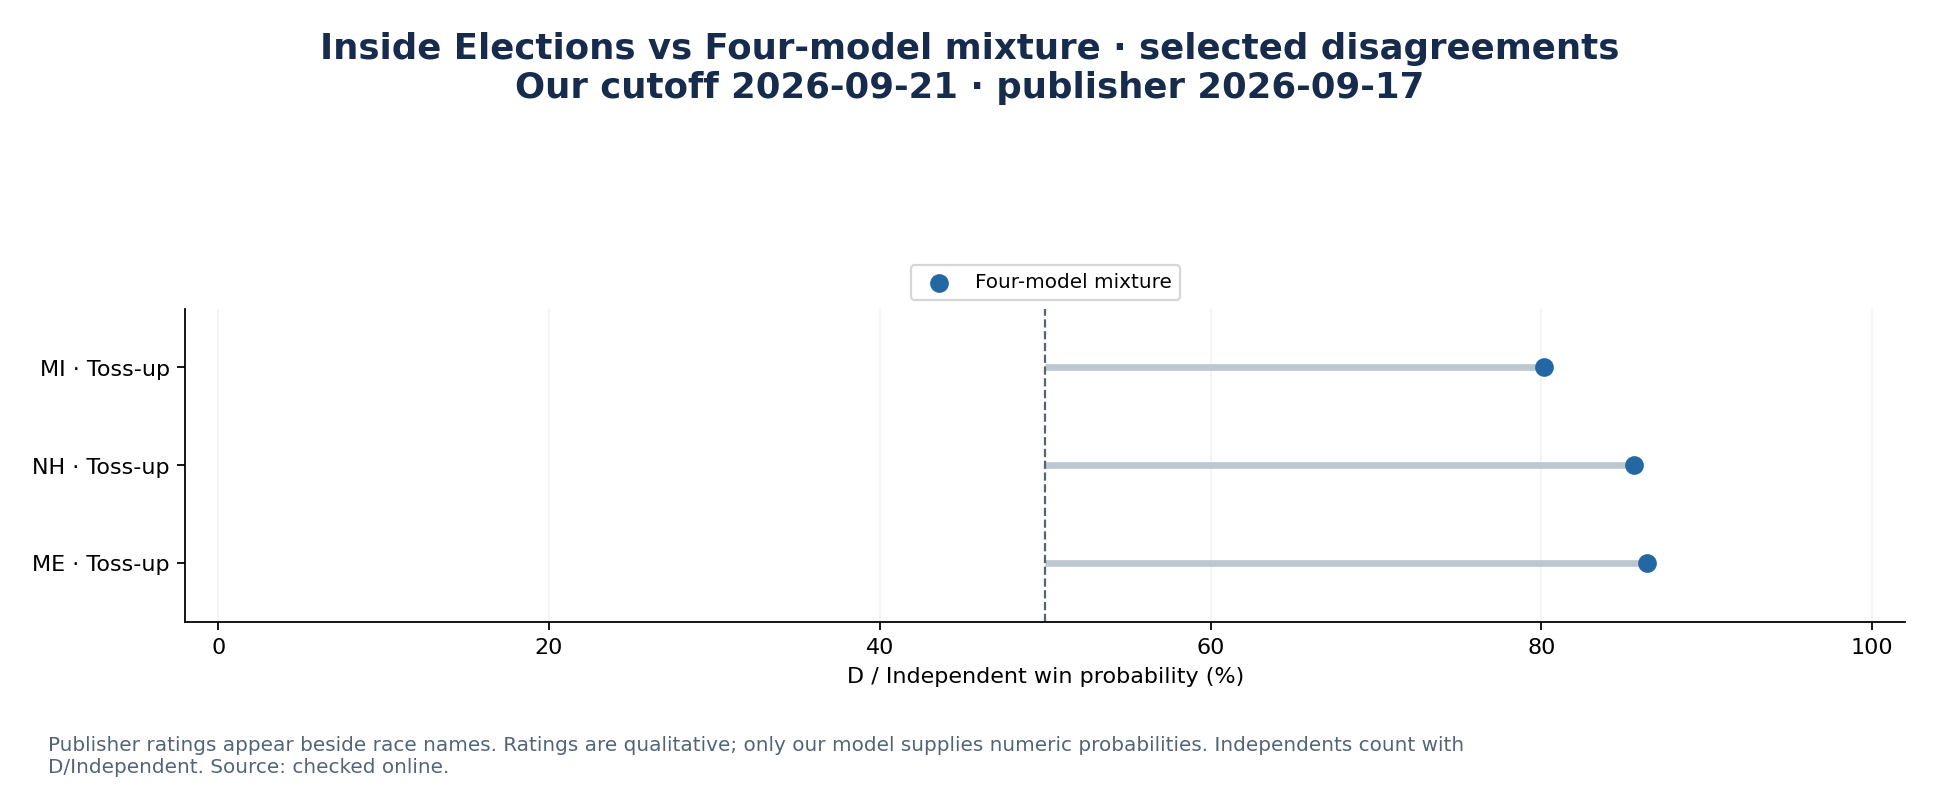

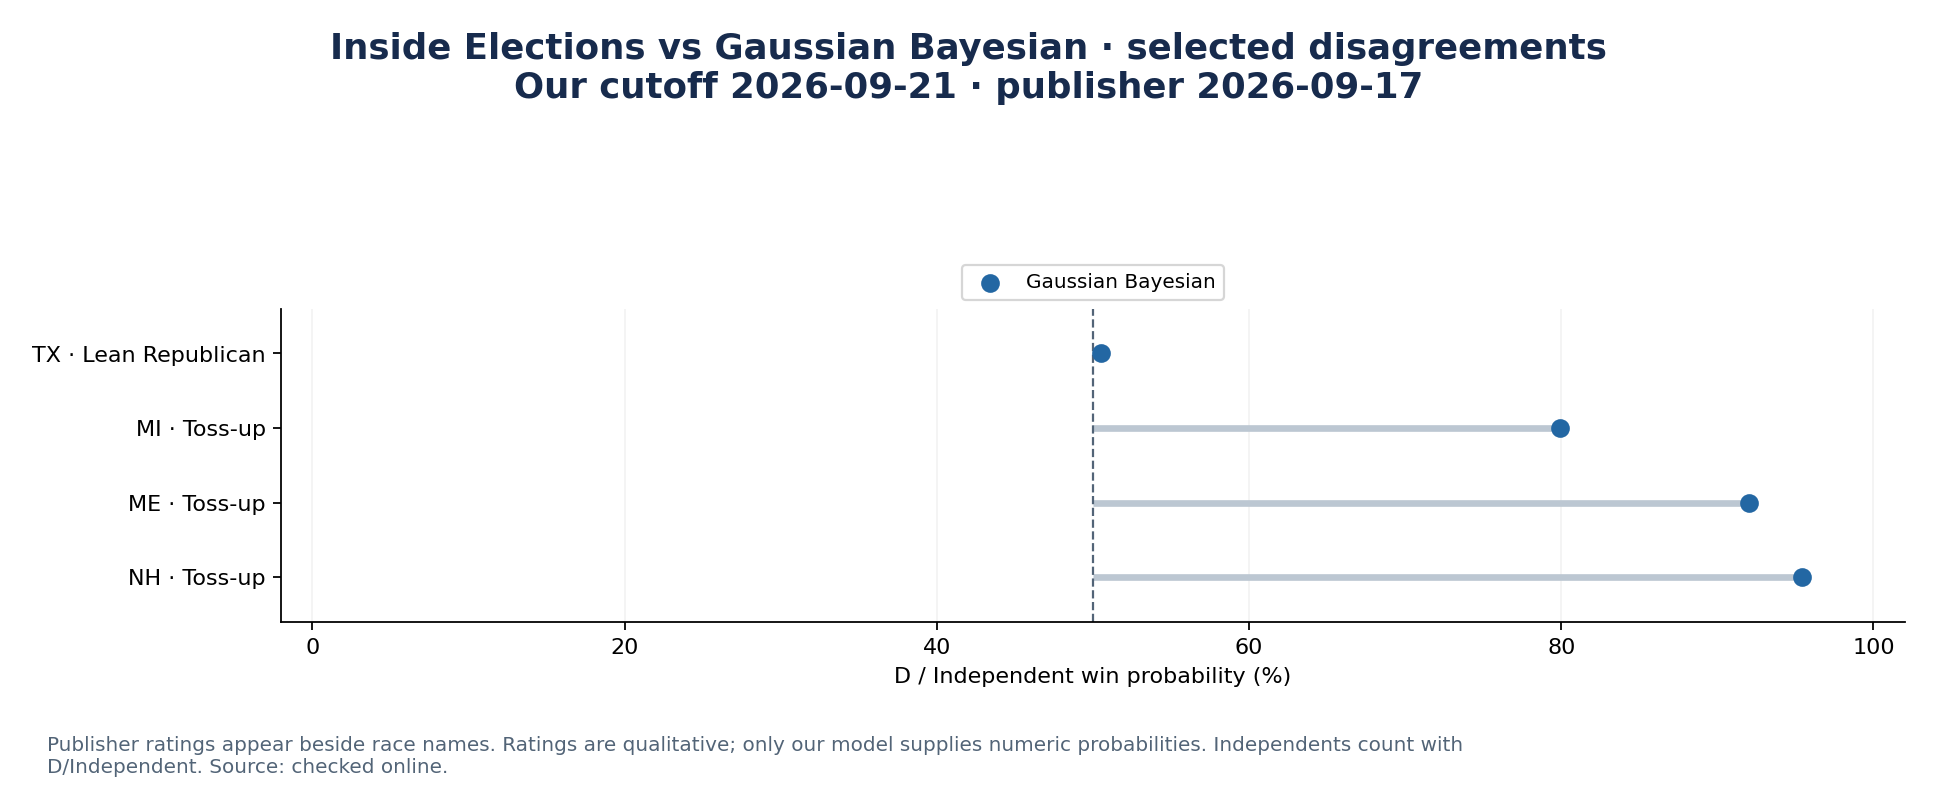

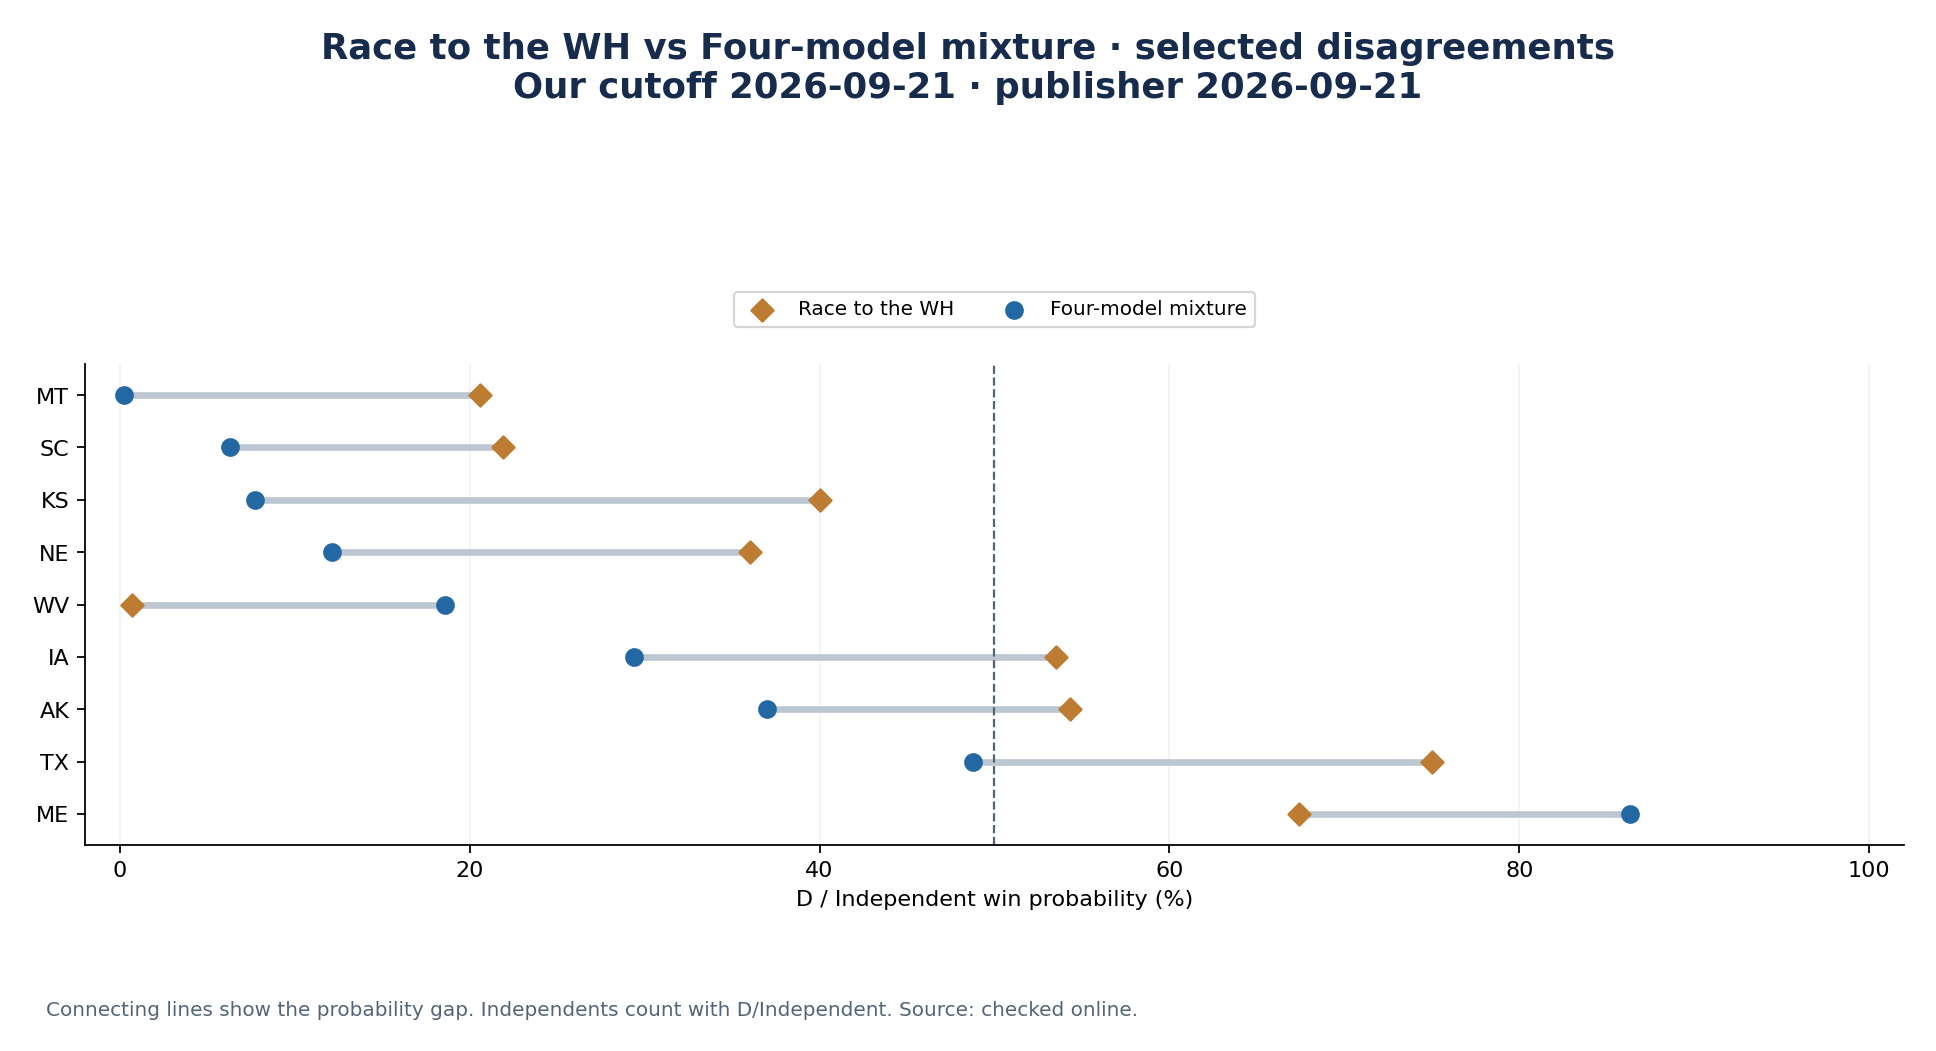

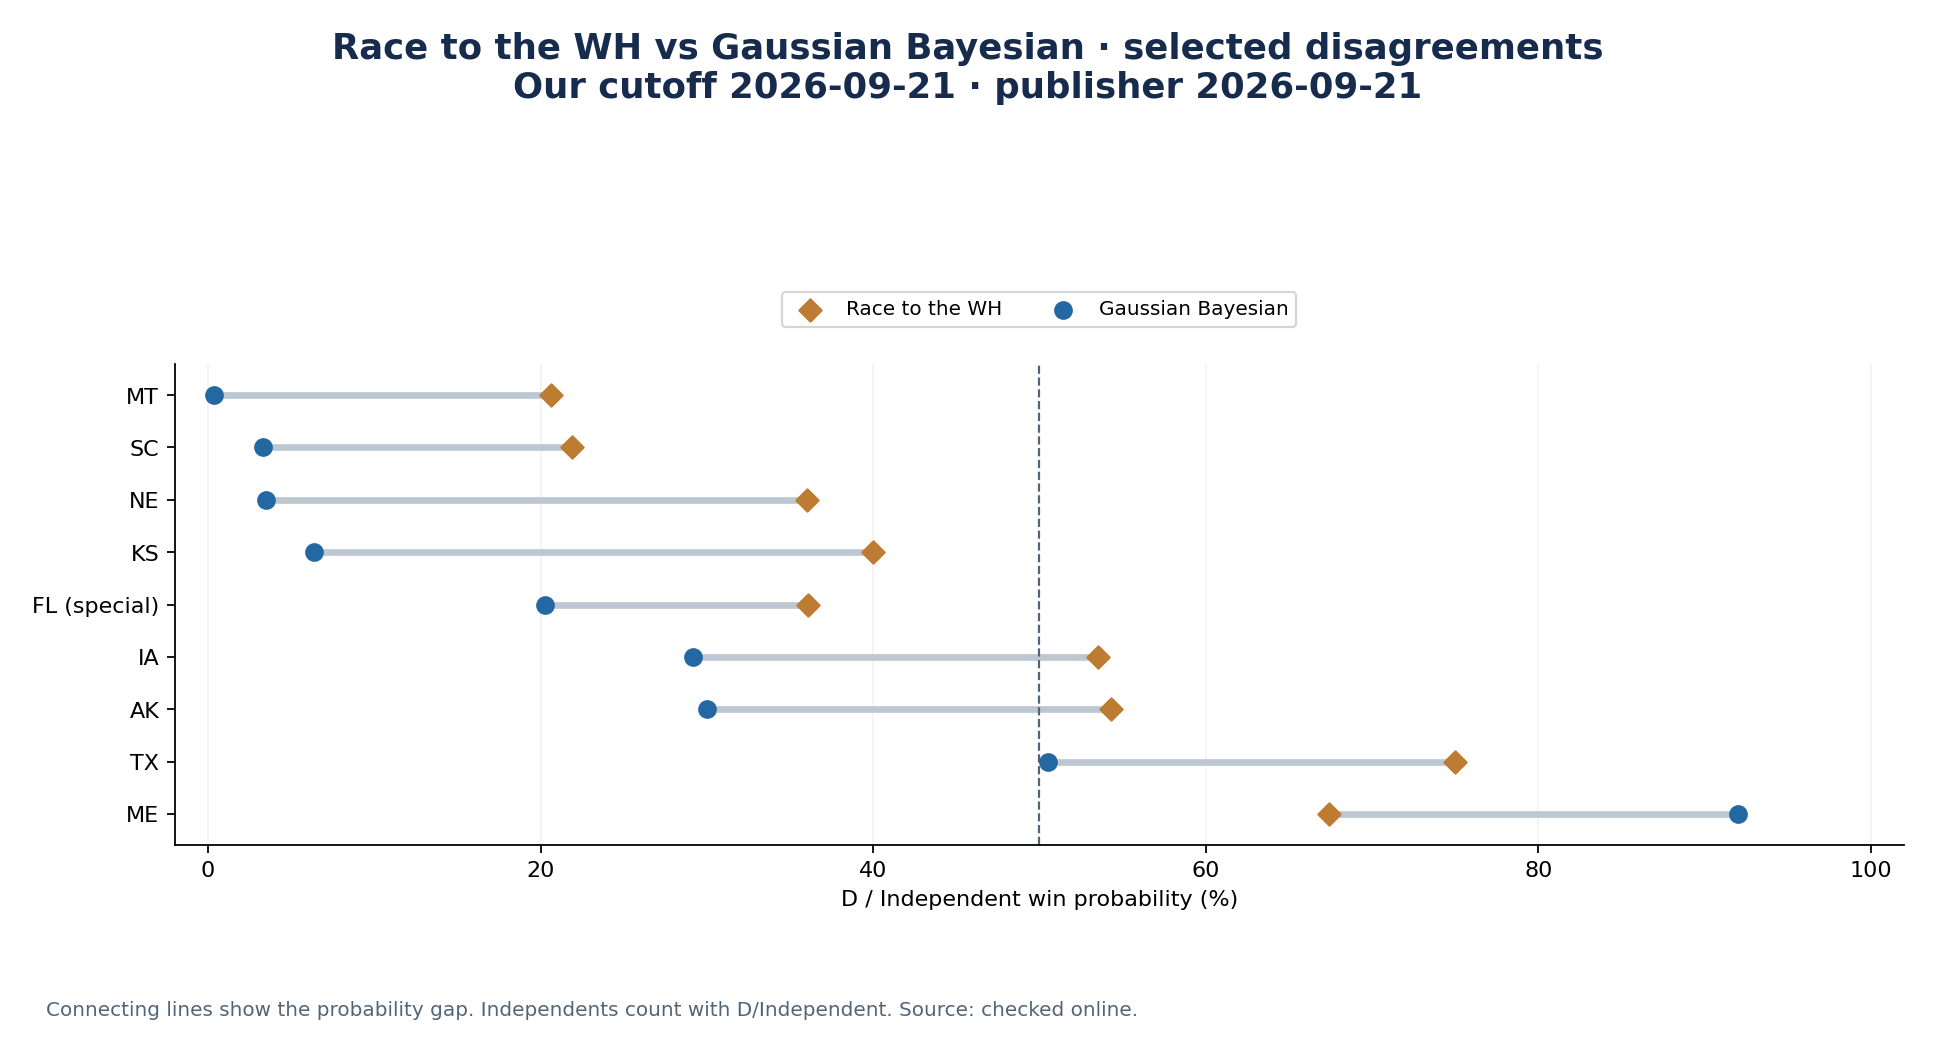

In [9]:
from live_published_comparison import build_published_comparison, render_comparison

PUBLISHED_GAP_PP = 15
PUBLISHED_RATING_CONFIDENCE = .75
PUBLISHED_MODELS = ('Bayesian', 'Four-model mixture')
published = build_published_comparison(
    RUN, offline=OFFLINE, force=FORCE, ttl_hours=TTL_HOURS, timeout=TIMEOUT_SECONDS,
    gap_pp=PUBLISHED_GAP_PP, confidence=PUBLISHED_RATING_CONFIDENCE, models=PUBLISHED_MODELS,
)
display(render_comparison(published))
display_images(published_images(published, SHARE_DIR, meta['as_of']))


## 6. Senate-control probabilities over cutoff dates

Reconstruct the direction of the forecast from January2026: evaluate every `HISTORY_EVERY_DAYS` days **plus each of the last three calendar days**, always including the endpoint. The default30-day grid is inexpensive; change it to7 for weekly detail. All models in the current live run are included, including every retained mean-shift weight. Republican control includes a50–50 Senate under the assumed Republican VP tie-break, so the two control probabilities sum to100%.

**This is a retrospective fixed-model replay, not a history of forecasts issued at the time.** Trained coefficients, priors, normalizers, hyperparameters, roster and screening rules stay fixed. Each cutoff rescreens polls by field-end and known release dates and recomputes decay. Unknown release dates use field-end dates; later archives cannot perfectly reconstruct publication availability or old candidate choices. `dated` also recomputes economic/approval features from reference periods ending by that cutoff, using today's revised source history. Those reference periods do not guarantee publication availability. `fixed_latest` is an optional polling-only sensitivity that deliberately holds today's features fixed.

The models were calibrated at September/October horizons, so January probabilities are exploratory. Small daily movements, particularly for Student models, may include Monte Carlo noise. The lines connect evaluated cutoffs, not daily forecasts between those dates. Student models run their actual samplers and convergence checks. Unchanged cutoff inputs reuse verified caches; changed inputs recompute.

A current-only HTML report is saved before the history starts, so it remains available even if a later replay fails. The following section then saves the complete report with the history. No existing forecast artifact is overwritten.


Current report saved: /Users/amir/projects/small_models/us_election_2026/cache/runs/live_reports/20260922T013137.432775Z/report.html


Cutoff 1/12: 2026-01-01 — computed


Cutoff 2/12: 2026-01-31 — computed


Cutoff 3/12: 2026-03-02 — computed


Cutoff 4/12: 2026-04-01 — computed


...

Political context: carrying forward the 2026-09-17 review; not independently reverified.


Cutoff 11/12: 2026-09-20 — computed


Cutoff 12/12: 2026-09-21 — current_live_run


Last daily cutoff probabilities (%), both parties and all models:


D_control_pct                       R_control_pct  \
date                         2026-09-19 2026-09-20 2026-09-21    2026-09-19   
model                                                                         
Gaussian Bayesian                 45.54      45.51      45.52         54.46   
Corrected 10%                     41.89      41.84      41.81         58.11   
Corrected 20%                     38.35      38.33      38.29         61.65   
Corrected 40%                     32.02      32.03      31.99         67.98   
Corrected 50%                     28.99      28.95      28.95         71.01   
Four-model mixture                55.18      55.15      55.14         44.82   
Matched Student-t (df5)           50.10      50.07      50.03         49.90   
Mixture + polling 10%             51.37      51.34      51.31         48.63   
Mixture + polling 20%             47.44      47.40      47.38         52.56   
Mixture + polling 30%             43.60      43.58      43.56         56.40   
Mixture + polling 40%             39.87      39.85      39.82         60.13   
Mixture + polling 5%              53.29      53.26      53.24         46.71   
Mixture + polling 50%             35.98      35.97      35.95         64.02   
Non-Bayesian corrected            16.35      16.35      16.35         83.65   
Older Gaussian                    62.04      62.00      62.00         37.96   
Student-t research helper         63.05      63.02      63.01         36.95   

                                                 
date                      2026-09-20 2026-09-21  
model                                            
Gaussian Bayesian              54.49      54.48  
Corrected 10%                  58.16      58.19  
Corrected 20%                  61.67      61.71  
Corrected 40%                  67.97      68.01  
Corrected 50%                  71.05      71.05  
Four-model mixture             44.85      44.86  
Matched Student-t (df5)        49.93      49.97  
Mixture + polling 10%          48.66      48.69  
Mixture + polling 20%          52.60      52.62  
Mixture + polling 30%          56.42      56.44  
Mixture + polling 40%          60.15      60.18  
Mixture + polling 5%           46.74      46.76  
Mixture + polling 50%          64.03      64.05  
Non-Bayesian corrected         83.65      83.65  
Older Gaussian                 38.00      38.00  
Student-t research helper      36.98      36.99

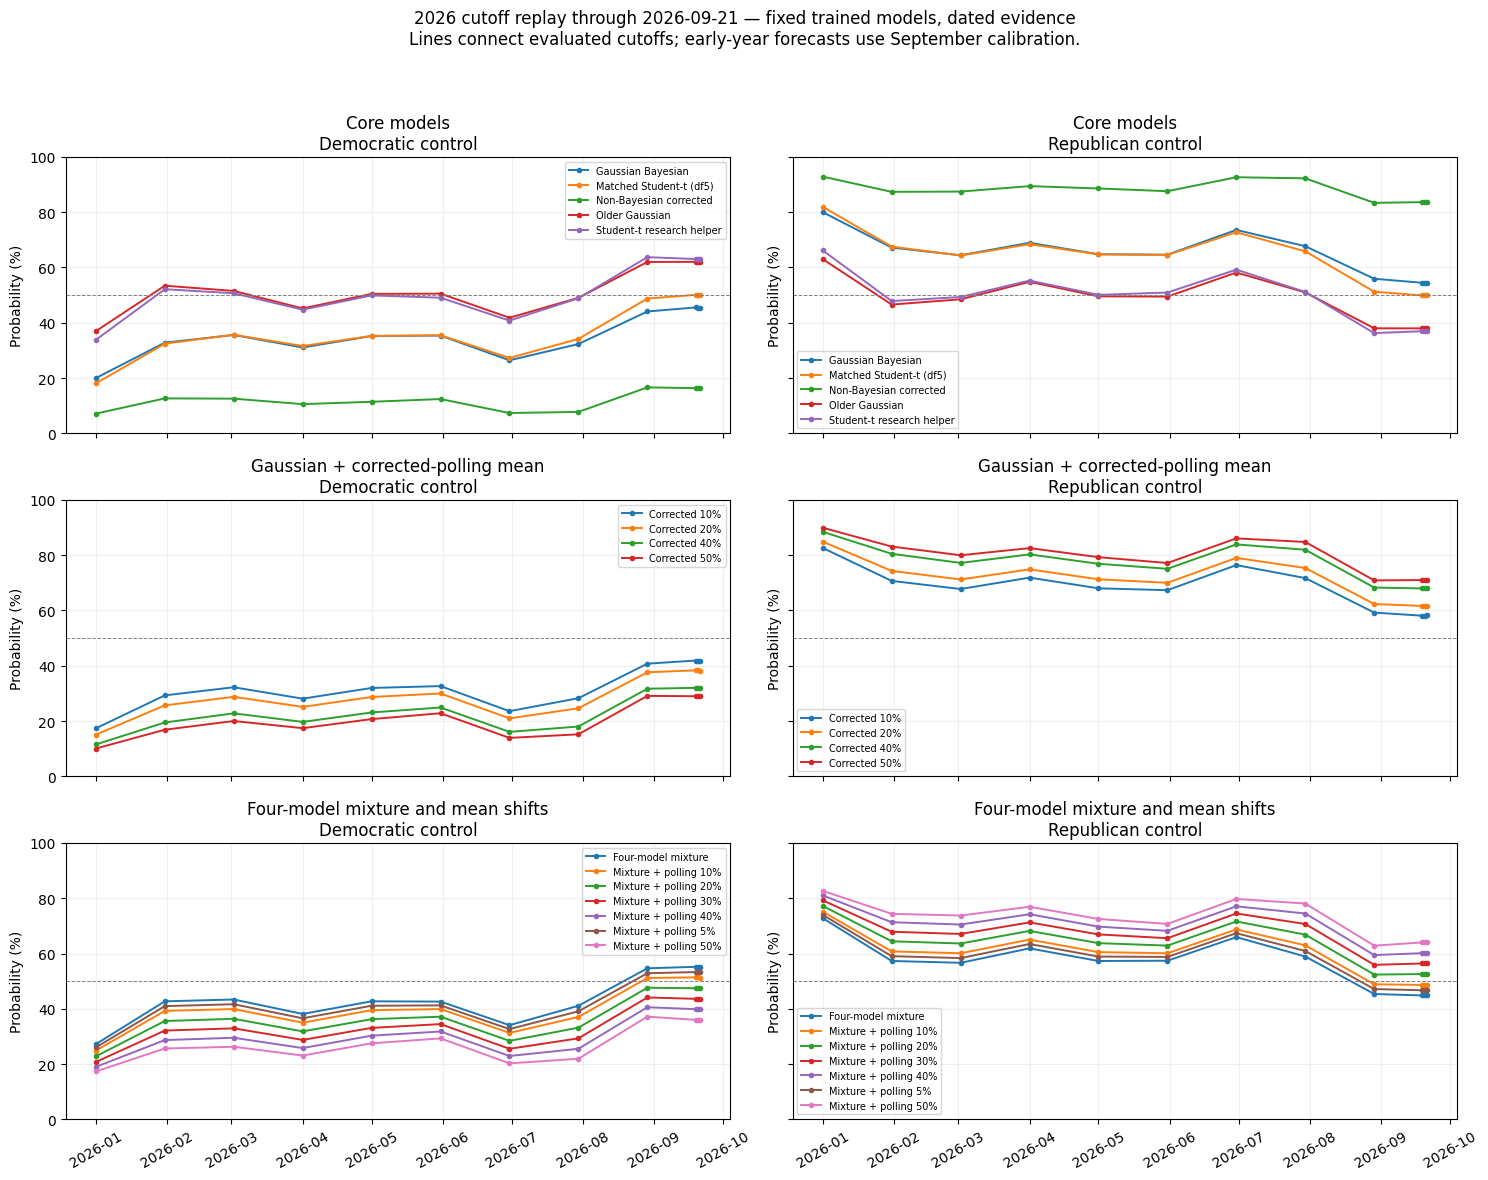

In [10]:
from live_forecast_report import run_history, history_figure, recent_table, save_report

HISTORY_START = '2026-01-01'
HISTORY_EVERY_DAYS = 30
HISTORY_LAST_DAYS = 3
HISTORY_FEATURE_MODE = 'dated'  # or 'fixed_latest' to isolate polling changes
HISTORY_FORCE = False

CURRENT_REPORT = save_report(RUN, watchlist, surprise=surprise, published=published)
print('Current report saved:', CURRENT_REPORT/'report.html')
HISTORY_RUN = run_history(
    RUN, start=HISTORY_START, every_days=HISTORY_EVERY_DAYS,
    last_days=HISTORY_LAST_DAYS, feature_mode=HISTORY_FEATURE_MODE, force=HISTORY_FORCE,
)
control_history = pd.read_parquet(HISTORY_RUN/'control_history.parquet')
print('Last daily cutoff probabilities (%), both parties and all models:')
display(recent_table(control_history, HISTORY_LAST_DAYS))
fig = history_figure(control_history)
SHARE_DIR.mkdir(parents=True, exist_ok=True)
fig.savefig(SHARE_DIR/'control_history.png', dpi=160, bbox_inches='tight')
plt.show()
plt.close(fig)


## 7. Save the complete report

Every Run All saves a timestamped **self-contained HTML report** with the current chamber/state forecasts, uncertainty watchlist, both-party control-history plots, recent daily tables, all cutoff results, polling coverage and provenance. Its chart is embedded, so the HTML file can be shared on its own. Machine-readable Parquet tables and a PNG chart are saved alongside it. The latest published report is under `outputs/reports/forecast/`; dated reports are under `outputs/reports/history/`.

Shareable PNG images are generated automatically for chamber results, state forecasts, watchlists and published comparisons. The original tables remain available. PNGs are saved alongside the latest report and frozen in the dated report folder.


In [11]:
import os

REPORT = save_report(RUN, watchlist, HISTORY_RUN, surprise=surprise, published=published)
print('Complete report saved:', REPORT/'report.html')
lab.verify_run(REPORT)

print('Shareable PNGs:', ROOT/'outputs/reports/forecast')
print('Dated reports and images:', ROOT/'outputs/reports/history')


Complete report saved: /Users/amir/projects/small_models/us_election_2026/cache/runs/live_reports/20260922T013256.240801Z/report.html
Shareable PNGs: /Users/amir/projects/small_models/us_election_2026/outputs/reports/forecast
Dated reports and images: /Users/amir/projects/small_models/us_election_2026/outputs/reports/history


## 8. Saved provenance and uncertainty checks

The entire run can be reopened by its path without following a later pointer. For an offline fresh recomputation use `python run.py live --offline`. For exact original research numbers use notebook01 instead.

In [12]:
lab.verify_run(RUN)
pred=pd.read_parquet(RUN/'predictions.parquet')
assert pred.actual_pp.isna().all()
if (RUN/'all_model_diagnostics.parquet').exists():
    d=pd.read_parquet(RUN/'all_model_diagnostics.parquet')
    display(d.groupby('model')[['rhat','bulk_ess','tail_ess']].agg(['min','max']).round(3))
print('Run manifest verified. No2026 outcomes were used. Historical comparisons: notebooks07/08.')

rhat         bulk_ess            tail_ess         
                           min    max       min      max        min      max
model                                                                       
Matched Student-t (df5)    1.0  1.001  6348.473  32000.0  13340.184  32000.0
Student-t research helper  1.0  1.002  5613.081  32000.0  10917.527  32000.0

Run manifest verified. No2026 outcomes were used. Historical comparisons: notebooks07/08.


## Saved reports

[Read the published report](../outputs/reports/forecast/report.md) · [All outputs and dated reports](../outputs/README.md)
